# animal0012.ipynb — Improved Animal Trend Research

This notebook extends `animal001.ipynb` with the suggested improvements:

1. **Equal-weight signal with risk-controlled execution**
2. **Trend ensemble**
   - EWMA crossover
   - time-series momentum
   - Donchian channel position
   - rolling regression slope t-stat
   - drawdown recovery trend
3. **Breadth filters**
4. **Volume / taker-buy confirmation**
5. **DOGE leader filters**
6. **Component-level top-N trend**
7. **Robustness tests**
8. **HAC and block-bootstrap p-value tests**
9. **Year-by-year and leave-one-coin-out checks**
10. **Leakage and correctness guardrails**

This notebook is research-only. It does not place trades.


## Research Goal

The earlier notebook found that:

- Equal-weight animal index had stronger returns than inverse-volatility.
- Trend-following improved drawdowns and Sharpe-like performance.
- DOGE was a major driver.

This notebook tests whether we can improve robustness and reduce dependency on a single coin.

Core question:

> Can we improve the animal trend strategy by using a better signal index, a trend ensemble, breadth/volume confirmation, DOGE leadership filters, and component-level selection?


## Strict Scientific Rules

We do **not** tune until something looks good.

Rules:

1. All rolling features use only current/past data.
2. All trading signals are shifted by one bar before earning returns.
3. Data availability is point-in-time.
4. New coins enter only after an entry delay.
5. We test costs and turnover.
6. We test year-by-year stability.
7. We test leave-one-coin-out dependency.
8. We report p-values but treat them as supporting evidence, not proof.
9. We prefer broad improvements over one magical parameter.
10. A result is not accepted if it only works because of DOGE.


## Part 1 — Setup


In [1]:
# Optional install:
# !python -m pip install pandas numpy matplotlib scipy statsmodels

from __future__ import annotations

from pathlib import Path
import math
import warnings
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

try:
    import statsmodels.api as sm
    HAS_STATSMODELS = True
except Exception:
    HAS_STATSMODELS = False

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

%matplotlib inline


In [2]:
# =========================
# Config
# =========================

DATA_DIR = Path("animal_4h_csv")
OUT_DIR = Path("animal0012_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

INTERVAL = "4h"
BARS_PER_DAY = 6
DAYS_PER_YEAR = 365
BARS_PER_YEAR = BARS_PER_DAY * DAYS_PER_YEAR

EXPECTED_SYMBOLS = [
    "DOGEUSDT",
    "POPCATUSDT",
    "PENGUUSDT",
    "1000PEPEUSDT",
    "WIFUSDT",
    "1000SHIBUSDT",
    "1000BONKUSDT",
]

FRIENDLY_NAMES = {
    "DOGEUSDT": "DOGE",
    "POPCATUSDT": "POPCAT",
    "PENGUUSDT": "PENGU",
    "1000PEPEUSDT": "PEPE",
    "WIFUSDT": "WIF",
    "1000SHIBUSDT": "SHIB",
    "1000BONKUSDT": "BONK",
}

DOGE_SYMBOL = "DOGEUSDT"

ENTRY_DELAY_DAYS = 7
ENTRY_DELAY_BARS = ENTRY_DELAY_DAYS * BARS_PER_DAY

VOL_LOOKBACK_DAYS = 60
VOL_LOOKBACK_BARS = VOL_LOOKBACK_DAYS * BARS_PER_DAY
MIN_VOL_PERIODS = 30 * BARS_PER_DAY

MAX_COIN_WEIGHT = 0.25

# Trend ensemble speeds
EWMA_SPEEDS = [(8, 32), (16, 64), (32, 128), (64, 256), (128, 512)]
TSMOM_DAYS = [3, 7, 14, 30, 60]
DONCHIAN_DAYS = [20, 40, 80]
REGRESSION_DAYS = [14, 30, 60]
DRAWDOWN_DAYS = [30, 90]

FORECAST_CAP = 20.0

# Trading
TARGET_VOL = 0.50
MAX_GROSS_EXPOSURE = 1.00
BASE_COST_BPS = 10.0  # fee + slippage proxy per unit turnover

# Entry filters / robustness
ENTRY_THRESHOLDS = [0, 2.5, 5, 7.5, 10]
BREADTH_THRESHOLDS = [0.40, 0.50, 0.60, 0.70]
VOLUME_Z_THRESHOLDS = [-0.5, 0.0, 0.5, 1.0]
DOGE_FILTER_MODES = ["none", "doge_trend_positive", "doge_above_30d_ma", "doge_leads_basket_7d"]

# Component selection
TOP_N_LIST = [2, 3, 4, 5]


## Part 2 — Load Data

Input is generated by `animal.py`.

Run first:

```bash
python animal.py --start 2019-09-01 --outdir animal_4h_csv
```


In [3]:
def load_symbol_csv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)

    required = {"symbol", "open_time", "open", "high", "low", "close", "volume"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{path} missing required columns: {sorted(missing)}")

    if np.issubdtype(df["open_time"].dtype, np.number):
        df["timestamp"] = pd.to_datetime(df["open_time"], unit="ms", utc=True)
    else:
        df["timestamp"] = pd.to_datetime(df["open_time"], utc=True, errors="coerce")

    numeric_cols = [
        "open", "high", "low", "close", "volume",
        "quote_asset_volume", "number_of_trades",
        "taker_buy_base_asset_volume", "taker_buy_quote_asset_volume",
    ]

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna(subset=["timestamp", "symbol", "close"])
    df = df.sort_values(["symbol", "timestamp"])
    return df


def load_all_csvs(data_dir: Path) -> pd.DataFrame:
    files = sorted(data_dir.glob(f"*_{INTERVAL}.csv"))

    if not files:
        raise FileNotFoundError(
            f"No *_{INTERVAL}.csv files found in {data_dir.resolve()}. "
            "Run animal.py first or update DATA_DIR."
        )

    frames = []
    for path in files:
        print(f"Loading {path}")
        frames.append(load_symbol_csv(path))

    return pd.concat(frames, ignore_index=True)


raw = load_all_csvs(DATA_DIR)

print("Raw shape:", raw.shape)
print("Symbols:", sorted(raw["symbol"].unique()))

missing = sorted(set(EXPECTED_SYMBOLS) - set(raw["symbol"].unique()))
if missing:
    print("WARNING missing expected symbols:", missing)

raw.head()


Loading animal_4h_csv/1000BONKUSDT_4h.csv
Loading animal_4h_csv/1000PEPEUSDT_4h.csv
Loading animal_4h_csv/1000SHIBUSDT_4h.csv
Loading animal_4h_csv/DOGEUSDT_4h.csv
Loading animal_4h_csv/PENGUUSDT_4h.csv
Loading animal_4h_csv/POPCATUSDT_4h.csv
Loading animal_4h_csv/WIFUSDT_4h.csv
Raw shape: (47041, 18)
Symbols: ['1000BONKUSDT', '1000PEPEUSDT', '1000SHIBUSDT', 'DOGEUSDT', 'PENGUUSDT', 'POPCATUSDT', 'WIFUSDT']


,symbol,interval,open_time,open_time_iso,open,high,low,close,volume,close_time,close_time_iso,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume,ignore,source_file,timestamp
0,1000BONKUSDT,4h,1700654400000,2023-11-22T12:00:00+00:00,0.004780,0.004825,0.004076,0.004252,"4,318,438,243.000000",1700668799999,2023-11-22T15:59:59.999000+00:00,"18,705,698.625350",90747,"2,103,402,174.000000","9,113,060.707592",0,1000BONKUSDT-4h-2023-11-22.csv,2023-11-22 12:00:00+00:00
1,1000BONKUSDT,4h,1700668800000,2023-11-22T16:00:00+00:00,0.004254,0.004739,0.004150,0.004621,"5,626,812,586.000000",1700683199999,2023-11-22T19:59:59.999000+00:00,"25,012,244.585627",142060,"2,769,270,394.000000","12,322,399.085503",0,1000BONKUSDT-4h-2023-11-22.csv,2023-11-22 16:00:00+00:00
2,1000BONKUSDT,4h,1700683200000,2023-11-22T20:00:00+00:00,0.004619,0.004776,0.004395,0.004531,"2,755,747,104.000000",1700697599999,2023-11-22T23:59:59.999000+00:00,"12,649,884.287770",87908,"1,312,260,664.000000","6,031,875.334290",0,1000BONKUSDT-4h-2023-11-22.csv,2023-11-22 20:00:00+00:00
3,1000BONKUSDT,4h,1700697600000,2023-11-23T00:00:00+00:00,0.004531,0.004858,0.004180,0.004316,"3,843,368,724.000000",1700711999999,2023-11-23T03:59:59.999000+00:00,"17,348,131.452764",117070,"1,814,259,183.000000","8,203,745.494474",0,1000BONKUSDT-4h-2023-11-23.csv,2023-11-23 00:00:00+00:00
4,1000BONKUSDT,4h,1700712000000,2023-11-23T04:00:00+00:00,0.004315,0.004402,0.004153,0.004309,"2,661,094,714.000000",1700726399999,2023-11-23T07:59:59.999000+00:00,"11,387,505.360771",75738,"1,222,483,991.000000","5,235,938.058663",0,1000BONKUSDT-4h-2023-11-23.csv,2023-11-23 04:00:00+00:00


## Part 3 — Data Quality

A strategy improvement is useless if data is stale or incomplete.


In [4]:
def data_quality_report(df: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for symbol, g in df.groupby("symbol"):
        g = g.sort_values("timestamp")
        start = g["timestamp"].min()
        end = g["timestamp"].max()

        expected_index = pd.date_range(start=start, end=end, freq=INTERVAL, tz="UTC")
        actual_index = pd.DatetimeIndex(g["timestamp"])

        bad_ohlc = (
            (g["high"] < g["low"]) |
            (g["open"] > g["high"]) |
            (g["open"] < g["low"]) |
            (g["close"] > g["high"]) |
            (g["close"] < g["low"]) |
            (g["volume"] < 0)
        )

        rows.append({
            "symbol": symbol,
            "friendly": FRIENDLY_NAMES.get(symbol, symbol),
            "start": start,
            "end": end,
            "rows": len(g),
            "expected_4h_bars": len(expected_index),
            "missing_4h_bars": int(len(expected_index.difference(actual_index))),
            "duplicate_bars": int(g.duplicated("timestamp").sum()),
            "zero_volume_bars": int((g["volume"].fillna(0) <= 0).sum()),
            "bad_ohlc_bars": int(bad_ohlc.sum()),
            "entry_date_after_delay": start + pd.Timedelta(days=ENTRY_DELAY_DAYS),
        })

    q = pd.DataFrame(rows).sort_values("start")
    latest = q["end"].max()
    q["stale_days_vs_latest"] = (latest - q["end"]).dt.total_seconds() / 86400
    return q


quality = data_quality_report(raw)
quality.to_csv(OUT_DIR / "data_quality_report.csv", index=False)
display(quality)

critical = quality[
    (quality["duplicate_bars"] > 0) |
    (quality["missing_4h_bars"] > 0) |
    (quality["bad_ohlc_bars"] > 0) |
    (quality["stale_days_vs_latest"] > 3)
]

if not critical.empty:
    print("WARNING: data quality issues detected. Fix before final conclusions.")
    display(critical)
else:
    print("PASS: data quality checks look clean.")


,symbol,friendly,start,end,rows,expected_4h_bars,missing_4h_bars,duplicate_bars,zero_volume_bars,bad_ohlc_bars,entry_date_after_delay,stale_days_vs_latest
3,DOGEUSDT,DOGE,2020-07-10 08:00:00+00:00,2026-04-26 20:00:00+00:00,12700,12700,0,0,0,0,2020-07-17 08:00:00+00:00,0.000000
2,1000SHIBUSDT,SHIB,2021-05-10 16:00:00+00:00,2026-04-26 20:00:00+00:00,10874,10874,0,0,0,0,2021-05-17 16:00:00+00:00,0.000000
1,1000PEPEUSDT,PEPE,2023-05-05 16:00:00+00:00,2026-04-26 20:00:00+00:00,6524,6524,0,0,0,0,2023-05-12 16:00:00+00:00,0.000000
0,1000BONKUSDT,BONK,2023-11-22 12:00:00+00:00,2026-04-26 20:00:00+00:00,5319,5319,0,0,0,0,2023-11-29 12:00:00+00:00,0.000000
6,WIFUSDT,WIF,2024-01-18 12:00:00+00:00,2026-04-26 20:00:00+00:00,4977,4977,0,0,0,0,2024-01-25 12:00:00+00:00,0.000000
5,POPCATUSDT,POPCAT,2024-08-22 12:00:00+00:00,2026-04-26 20:00:00+00:00,3675,3675,0,0,0,0,2024-08-29 12:00:00+00:00,0.000000
4,PENGUUSDT,PENGU,2024-12-17 16:00:00+00:00,2026-04-26 20:00:00+00:00,2972,2972,0,0,0,0,2024-12-24 16:00:00+00:00,0.000000


PASS: data quality checks look clean.


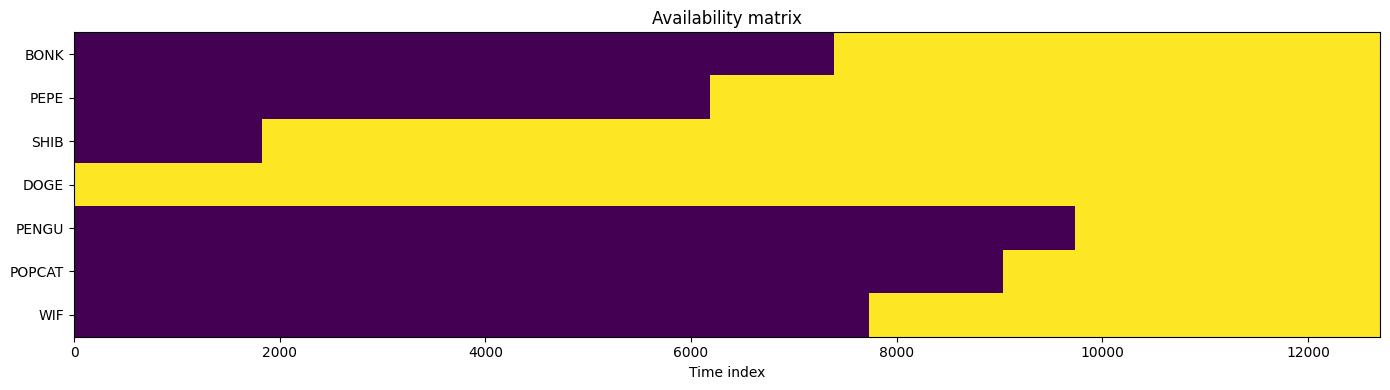

In [5]:
close_raw = raw.pivot_table(index="timestamp", columns="symbol", values="close", aggfunc="last").sort_index()
availability = close_raw.notna().astype(int)

fig, ax = plt.subplots(figsize=(14, 4))
ax.imshow(availability.T.values, aspect="auto", interpolation="nearest")
ax.set_title("Availability matrix")
ax.set_yticks(range(len(availability.columns)))
ax.set_yticklabels([FRIENDLY_NAMES.get(s, s) for s in availability.columns])
ax.set_xlabel("Time index")
plt.tight_layout()
plt.savefig(OUT_DIR / "availability_matrix.png", dpi=150)
plt.show()


## Part 4 — Build Panels


In [6]:
def make_panel(df: pd.DataFrame, value_col: str) -> pd.DataFrame:
    if value_col not in df.columns:
        return pd.DataFrame(index=sorted(df["timestamp"].unique()))
    return df.pivot_table(index="timestamp", columns="symbol", values=value_col, aggfunc="last").sort_index()


open_panel = make_panel(raw, "open")
high_panel = make_panel(raw, "high")
low_panel = make_panel(raw, "low")
close_panel = make_panel(raw, "close")
volume_panel = make_panel(raw, "volume")
quote_volume_panel = make_panel(raw, "quote_asset_volume")
trade_count_panel = make_panel(raw, "number_of_trades")
taker_buy_quote_panel = make_panel(raw, "taker_buy_quote_asset_volume")

simple_returns = close_panel.pct_change(fill_method=None)
log_returns = np.log(close_panel / close_panel.shift(1))
taker_buy_ratio_panel = taker_buy_quote_panel / quote_volume_panel.replace(0, np.nan)

close_panel.to_csv(OUT_DIR / "close_panel.csv")
simple_returns.to_csv(OUT_DIR / "simple_returns.csv")

print("Close panel:", close_panel.shape)
print("Return panel:", simple_returns.shape)


Close panel: (12700, 7)
Return panel: (12700, 7)


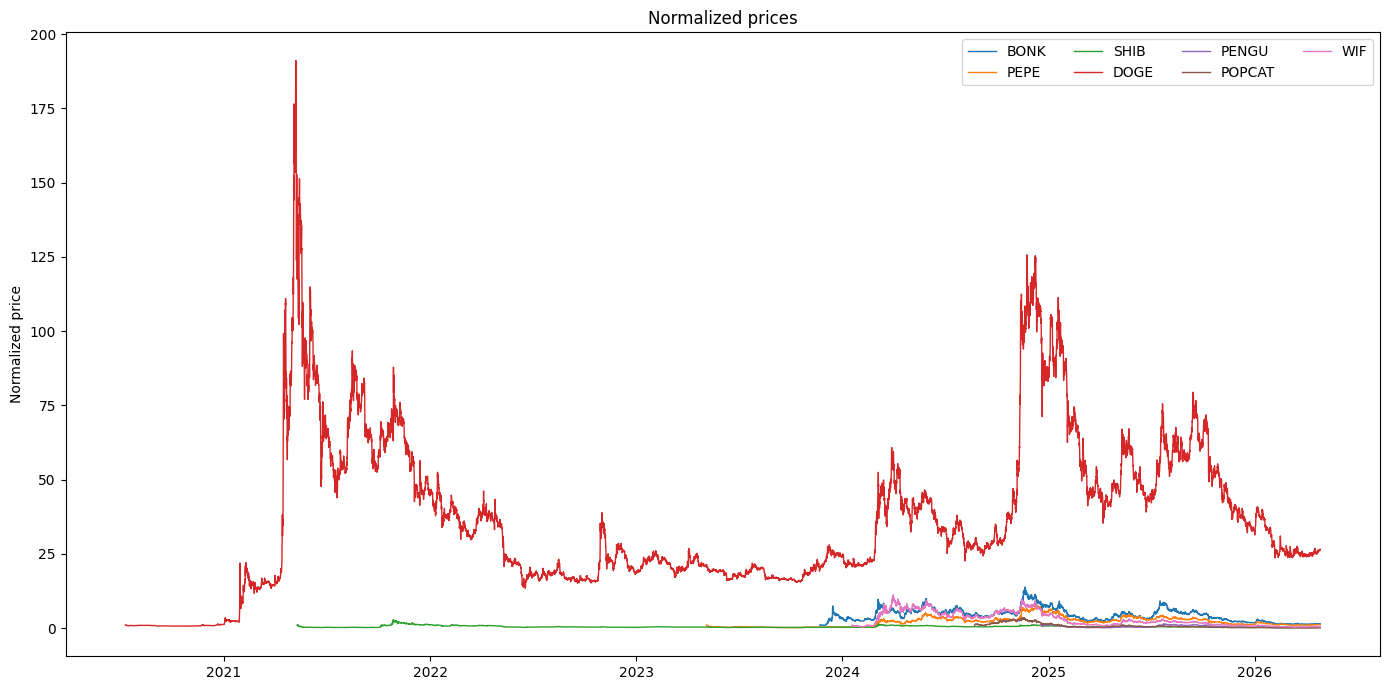

In [7]:
norm_prices = close_panel / close_panel.apply(lambda s: s.dropna().iloc[0] if s.dropna().shape[0] else np.nan)

fig, ax = plt.subplots(figsize=(14, 7))
for col in norm_prices.columns:
    ax.plot(norm_prices.index, norm_prices[col], label=FRIENDLY_NAMES.get(col, col), linewidth=1)

ax.set_title("Normalized prices")
ax.set_ylabel("Normalized price")
ax.legend(ncol=4)
plt.tight_layout()
plt.savefig(OUT_DIR / "normalized_prices.png", dpi=150)
plt.show()


## Part 5 — Core Helpers


In [8]:
def equity_from_returns(r: pd.Series, start_value: float = 100.0) -> pd.Series:
    return start_value * (1.0 + r.fillna(0.0)).cumprod()


def max_drawdown(equity: pd.Series) -> float:
    e = equity.dropna()
    if e.empty:
        return np.nan
    return float((e / e.cummax() - 1.0).min())


def drawdown_series(equity: pd.Series) -> pd.Series:
    e = equity.dropna()
    return e / e.cummax() - 1.0


def perf_stats(r: pd.Series, name: str) -> dict:
    r = r.dropna()
    if r.empty:
        return {"name": name}

    eq = equity_from_returns(r)
    years = len(r) / BARS_PER_YEAR
    total_return = eq.iloc[-1] / eq.iloc[0] - 1.0
    cagr = (eq.iloc[-1] / eq.iloc[0]) ** (1 / years) - 1 if years > 0 else np.nan
    ann_mean = r.mean() * BARS_PER_YEAR
    ann_vol = r.std(ddof=1) * math.sqrt(BARS_PER_YEAR)
    sharpe_like = ann_mean / ann_vol if ann_vol and ann_vol > 0 else np.nan
    mdd = max_drawdown(eq)
    calmar = cagr / abs(mdd) if mdd and mdd < 0 else np.nan

    return {
        "name": name,
        "start": r.index.min(),
        "end": r.index.max(),
        "bars": len(r),
        "years": years,
        "total_return": total_return,
        "cagr": cagr,
        "ann_mean": ann_mean,
        "ann_vol": ann_vol,
        "sharpe_like": sharpe_like,
        "max_drawdown": mdd,
        "calmar": calmar,
        "hit_rate": (r > 0).mean(),
        "best_bar": r.max(),
        "worst_bar": r.min(),
        "skew": r.skew(),
        "kurtosis": r.kurtosis(),
    }


def hac_mean_test(x: pd.Series, maxlags: int) -> dict:
    x = x.dropna()

    if len(x) < 50:
        return {"n": len(x), "mean": np.nan, "t": np.nan, "p_greater": np.nan, "p_two_sided": np.nan}

    if HAS_STATSMODELS:
        X = np.ones((len(x), 1))
        model = sm.OLS(x.values, X).fit(cov_type="HAC", cov_kwds={"maxlags": maxlags})
        mean = model.params[0]
        tval = model.tvalues[0]
        p_two = model.pvalues[0]
        p_greater = 1.0 - stats.t.cdf(tval, df=max(len(x) - 1, 1))
        return {"n": len(x), "mean": mean, "t": tval, "p_greater": p_greater, "p_two_sided": p_two}

    tval, p_two = stats.ttest_1samp(x.values, popmean=0.0)
    mean = x.mean()
    p_greater = p_two / 2 if tval > 0 else 1 - p_two / 2
    return {"n": len(x), "mean": mean, "t": tval, "p_greater": p_greater, "p_two_sided": p_two}


def block_bootstrap_mean_pvalue(
    x: pd.Series,
    block_size: int,
    n_boot: int = 1000,
    alternative: str = "greater",
    random_state: int = 42,
) -> dict:
    x = x.dropna().values.astype(float)
    n = len(x)

    if n < block_size * 3:
        return {"n": n, "observed_mean": np.nan, "p": np.nan}

    rng = np.random.default_rng(random_state)
    observed = x.mean()
    centered = x - observed
    starts = np.arange(0, n - block_size + 1)

    boot = []
    for _ in range(n_boot):
        pieces = []
        total = 0

        while total < n:
            start = rng.choice(starts)
            b = centered[start:start + block_size]
            pieces.append(b)
            total += len(b)

        sample = np.concatenate(pieces)[:n]
        boot.append(sample.mean())

    boot = np.array(boot)

    if alternative == "greater":
        p = (np.sum(boot >= observed) + 1) / (len(boot) + 1)
    elif alternative == "less":
        p = (np.sum(boot <= observed) + 1) / (len(boot) + 1)
    else:
        p = (np.sum(np.abs(boot) >= abs(observed)) + 1) / (len(boot) + 1)

    return {"n": n, "observed_mean": observed, "p": float(p)}


def evidence_label(p: float) -> str:
    if pd.isna(p):
        return "NA"
    if p <= 1e-5:
        return "too_small_check_leakage"
    if p < 0.05:
        return "candidate_evidence"
    return "weak_evidence"


## Part 6 — Point-in-Time Index Construction

We build:

1. Equal-weight index
2. Inverse-volatility index
3. Capped equal-weight index

This notebook emphasizes using **equal-weight as signal** and **vol targeting as risk control**.


In [9]:
def cap_and_normalize_row(row: pd.Series, cap: float) -> pd.Series:
    x = row.astype(float).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    x = x.clip(lower=0.0)

    if x.sum() <= 0:
        return pd.Series(np.nan, index=row.index)

    w = x / x.sum()

    for _ in range(len(w) + 2):
        over = w > cap
        if not over.any():
            break

        w[over] = cap
        under = ~over
        remaining = 1.0 - w[over].sum()

        if remaining <= 0 or under.sum() == 0:
            w[under] = 0.0
            break

        under_sum = w[under].sum()
        if under_sum <= 0:
            w[under] = remaining / under.sum()
        else:
            w[under] = w[under] / under_sum * remaining

    return w / w.sum() if w.sum() > 0 else w


def eligibility_matrix(returns: pd.DataFrame, entry_delay_bars: int) -> pd.DataFrame:
    obs_count = returns.notna().cumsum()
    return (obs_count > entry_delay_bars) & returns.notna()


def equal_weight_matrix(returns: pd.DataFrame, eligible: pd.DataFrame) -> pd.DataFrame:
    raw = eligible.astype(float)
    denom = raw.sum(axis=1).replace(0, np.nan)
    return raw.div(denom, axis=0)


def capped_equal_weight_matrix(returns: pd.DataFrame, eligible: pd.DataFrame, cap: float) -> pd.DataFrame:
    ew = equal_weight_matrix(returns, eligible)
    return ew.apply(lambda row: cap_and_normalize_row(row, cap=cap), axis=1)


def inverse_vol_weight_matrix(
    returns: pd.DataFrame,
    eligible: pd.DataFrame,
    lookback_bars: int,
    min_periods: int,
    cap: float,
) -> pd.DataFrame:
    ann_vol = returns.shift(1).rolling(lookback_bars, min_periods=min_periods).std() * math.sqrt(BARS_PER_YEAR)
    inv = 1.0 / ann_vol.replace(0, np.nan)
    inv = inv.where(eligible)
    raw = inv.div(inv.sum(axis=1), axis=0)
    return raw.apply(lambda row: cap_and_normalize_row(row, cap=cap), axis=1)


def portfolio_returns(asset_returns: pd.DataFrame, weights: pd.DataFrame) -> pd.Series:
    r, w = asset_returns.align(weights, join="inner", axis=0)
    return (r * w).sum(axis=1, min_count=1)


eligible = eligibility_matrix(simple_returns, ENTRY_DELAY_BARS)

ew_weights = equal_weight_matrix(simple_returns, eligible)
cew_weights = capped_equal_weight_matrix(simple_returns, eligible, MAX_COIN_WEIGHT)
iv_weights = inverse_vol_weight_matrix(
    simple_returns,
    eligible,
    VOL_LOOKBACK_BARS,
    MIN_VOL_PERIODS,
    MAX_COIN_WEIGHT,
)

ew_r = portfolio_returns(simple_returns, ew_weights).rename("equal_weight")
cew_r = portfolio_returns(simple_returns, cew_weights).rename("capped_equal_weight")
iv_r = portfolio_returns(simple_returns, iv_weights).rename("inverse_vol")

index_returns = pd.concat([ew_r, cew_r, iv_r], axis=1).dropna(how="all")
index_returns.to_csv(OUT_DIR / "index_returns.csv")

display(index_returns.tail())


,equal_weight,capped_equal_weight,inverse_vol
timestamp,,,
2026-04-26 04:00:00+00:00,0.014018,0.014018,0.013425
2026-04-26 08:00:00+00:00,0.008543,0.008543,0.007952
2026-04-26 12:00:00+00:00,-0.007141,-0.007141,-0.006487
2026-04-26 16:00:00+00:00,0.003534,0.003534,0.002985
2026-04-26 20:00:00+00:00,-0.000629,-0.000629,-0.000443


,name,start,end,bars,years,total_return,cagr,ann_mean,ann_vol,sharpe_like,max_drawdown,calmar,hit_rate,best_bar,worst_bar,skew,kurtosis
0,equal_weight_buyhold,2020-07-17 12:00:00+00:00,2026-04-26 20:00:00+00:00,12657,5.779452,123.314622,1.303607,1.738120,1.408280,1.234215,-0.879445,1.482307,0.499960,1.253744,-0.372638,7.899070,279.587071
1,capped_equal_weight_buyhold,2020-07-17 12:00:00+00:00,2026-04-26 20:00:00+00:00,12657,5.779452,7.137010,0.437258,0.727396,0.856969,0.848801,-0.879445,0.497198,0.500198,0.313436,-0.213498,0.835571,20.222661
2,inverse_vol_buyhold,2020-08-09 12:00:00+00:00,2026-04-26 20:00:00+00:00,12519,5.716438,4.530722,0.348770,0.654477,0.846757,0.772923,-0.874985,0.398601,0.499720,0.313436,-0.208116,0.833317,20.587747


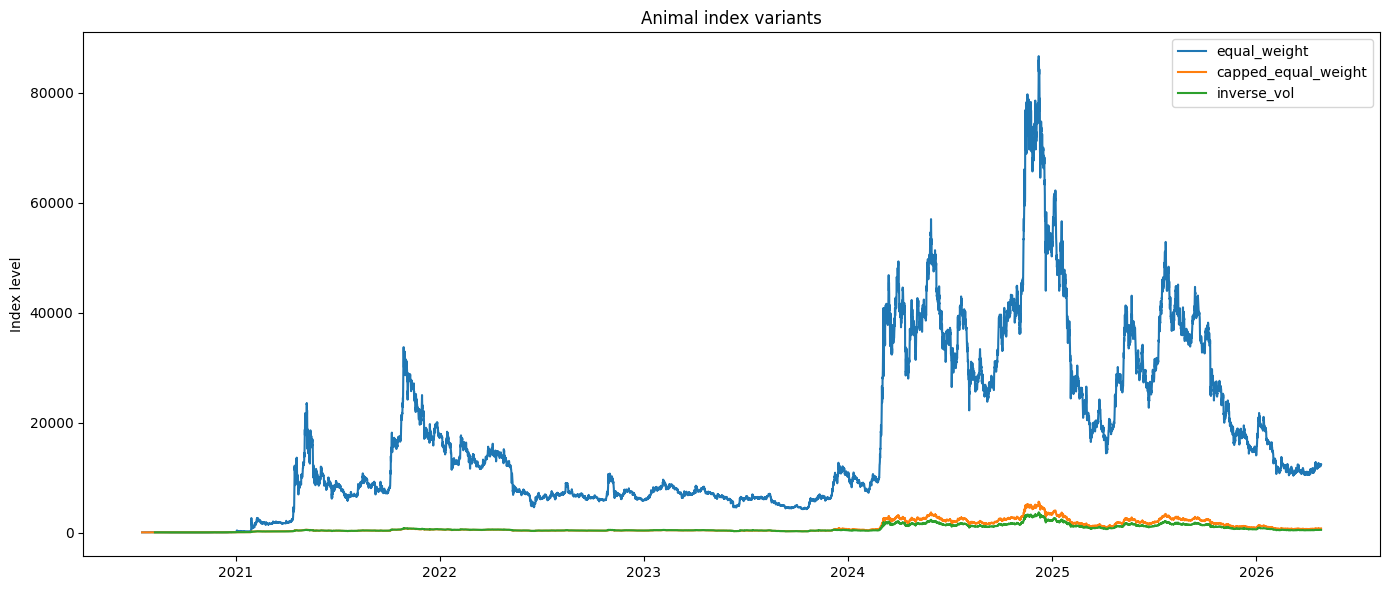

In [10]:
index_metrics = pd.DataFrame([
    perf_stats(index_returns["equal_weight"], "equal_weight_buyhold"),
    perf_stats(index_returns["capped_equal_weight"], "capped_equal_weight_buyhold"),
    perf_stats(index_returns["inverse_vol"], "inverse_vol_buyhold"),
])

display(index_metrics)
index_metrics.to_csv(OUT_DIR / "index_metrics.csv", index=False)

fig, ax = plt.subplots(figsize=(14, 6))
for col in index_returns.columns:
    ax.plot(equity_from_returns(index_returns[col].dropna()), label=col)
ax.set_title("Animal index variants")
ax.set_ylabel("Index level")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "index_variants_equity.png", dpi=150)
plt.show()


## Part 7 — Trend Ensemble Components

We build multiple trend definitions:

1. EWMA crossover forecast
2. Time-series momentum forecast
3. Donchian channel forecast
4. Rolling regression slope t-stat forecast
5. Drawdown recovery forecast


In [11]:
def robust_clip_forecast(x: pd.Series, cap: float = FORECAST_CAP) -> pd.Series:
    return x.replace([np.inf, -np.inf], np.nan).clip(-cap, cap)


def ewma_forecast(price: pd.Series, fast: int, slow: int) -> pd.Series:
    fast_ma = price.ewm(span=fast, adjust=False).mean()
    slow_ma = price.ewm(span=slow, adjust=False).mean()
    raw = fast_ma / slow_ma - 1.0

    r = price.pct_change()
    vol_per_bar = r.rolling(VOL_LOOKBACK_BARS, min_periods=max(20, VOL_LOOKBACK_BARS // 3)).std()
    z = raw / vol_per_bar.replace(0, np.nan)
    return robust_clip_forecast(z * 2.5)


def tsmom_forecast(price: pd.Series, days: int, vol_days: int = 60) -> pd.Series:
    bars = days * BARS_PER_DAY
    vol_bars = vol_days * BARS_PER_DAY
    r = price.pct_change()

    past_ret = price / price.shift(bars) - 1.0
    vol = r.rolling(vol_bars, min_periods=max(20, vol_bars // 3)).std() * math.sqrt(bars)
    z = past_ret / vol.replace(0, np.nan)
    return robust_clip_forecast(z * 8.0)


def donchian_forecast(price: pd.Series, days: int) -> pd.Series:
    bars = days * BARS_PER_DAY
    hi = price.rolling(bars, min_periods=max(10, bars // 3)).max()
    lo = price.rolling(bars, min_periods=max(10, bars // 3)).min()
    pos = (price - lo) / (hi - lo).replace(0, np.nan)

    # map 0..1 to -20..+20
    return robust_clip_forecast((pos - 0.5) * 40.0)


def rolling_regression_tstat_forecast(price: pd.Series, days: int) -> pd.Series:
    bars = days * BARS_PER_DAY
    logp = np.log(price.replace(0, np.nan))

    out = pd.Series(index=price.index, dtype=float)
    x = np.arange(bars, dtype=float)
    x = x - x.mean()
    denom = np.sum(x ** 2)

    for i in range(bars - 1, len(logp)):
        y = logp.iloc[i - bars + 1:i + 1].values
        if np.any(~np.isfinite(y)):
            out.iloc[i] = np.nan
            continue

        y_centered = y - y.mean()
        beta = np.sum(x * y_centered) / denom
        residual = y_centered - beta * x
        resid_std = np.sqrt(np.sum(residual ** 2) / max(bars - 2, 1))
        beta_se = resid_std / np.sqrt(denom) if denom > 0 else np.nan
        tstat = beta / beta_se if beta_se and beta_se > 0 else np.nan
        out.iloc[i] = tstat

    return robust_clip_forecast(out * 3.0)


def drawdown_recovery_forecast(price: pd.Series, days: int) -> pd.Series:
    bars = days * BARS_PER_DAY
    rolling_high = price.rolling(bars, min_periods=max(10, bars // 3)).max()
    rolling_low = price.rolling(bars, min_periods=max(10, bars // 3)).min()

    drawdown = price / rolling_high - 1.0
    recovery = price / rolling_low - 1.0

    # Want positive signal when recovering strongly but not still collapsed.
    raw = recovery + drawdown
    vol = price.pct_change().rolling(bars, min_periods=max(10, bars // 3)).std()
    z = raw / vol.replace(0, np.nan)
    return robust_clip_forecast(z * 0.5)


In [12]:
def build_trend_ensemble(index_return: pd.Series, name: str) -> pd.DataFrame:
    price = equity_from_returns(index_return.dropna())
    parts = []

    for fast, slow in EWMA_SPEEDS:
        parts.append(ewma_forecast(price, fast, slow).rename(f"{name}_ewma_{fast}_{slow}"))

    for d in TSMOM_DAYS:
        parts.append(tsmom_forecast(price, d).rename(f"{name}_tsmom_{d}d"))

    for d in DONCHIAN_DAYS:
        parts.append(donchian_forecast(price, d).rename(f"{name}_donchian_{d}d"))

    for d in REGRESSION_DAYS:
        parts.append(rolling_regression_tstat_forecast(price, d).rename(f"{name}_regression_t_{d}d"))

    for d in DRAWDOWN_DAYS:
        parts.append(drawdown_recovery_forecast(price, d).rename(f"{name}_drawdown_recovery_{d}d"))

    out = pd.concat(parts, axis=1)
    out[f"{name}_ensemble_mean"] = out.mean(axis=1)
    out[f"{name}_ensemble_vote"] = (out > 0).sum(axis=1) - (out < 0).sum(axis=1)
    out[f"{name}_ensemble_vote_forecast"] = (out[f"{name}_ensemble_vote"] / len(parts) * FORECAST_CAP).clip(-FORECAST_CAP, FORECAST_CAP)

    return out


ew_ensemble = build_trend_ensemble(index_returns["equal_weight"], "ew")
cew_ensemble = build_trend_ensemble(index_returns["capped_equal_weight"], "cew")
iv_ensemble = build_trend_ensemble(index_returns["inverse_vol"], "iv")

ew_ensemble.to_csv(OUT_DIR / "ew_trend_ensemble.csv")
cew_ensemble.to_csv(OUT_DIR / "cew_trend_ensemble.csv")
iv_ensemble.to_csv(OUT_DIR / "iv_trend_ensemble.csv")

display(ew_ensemble.tail())


,ew_ewma_8_32,ew_ewma_16_64,ew_ewma_32_128,ew_ewma_64_256,ew_ewma_128_512,ew_tsmom_3d,ew_tsmom_7d,ew_tsmom_14d,ew_tsmom_30d,ew_tsmom_60d,ew_donchian_20d,ew_donchian_40d,ew_donchian_80d,ew_regression_t_14d,ew_regression_t_30d,ew_regression_t_60d,ew_drawdown_recovery_30d,ew_drawdown_recovery_90d,ew_ensemble_mean,ew_ensemble_vote,ew_ensemble_vote_forecast
timestamp,,,,,,,,,,,,,,,,,,,,,
2026-04-26 04:00:00+00:00,0.470087,2.212537,5.319863,5.105659,-9.506174,2.159751,3.278047,6.519899,4.241268,2.637052,11.482045,11.993931,3.122022,20.000000,20.000000,20.000000,4.779880,-1.886659,6.218289,15,16.666667
2026-04-26 08:00:00+00:00,0.932475,2.415115,5.400167,5.193553,-9.378438,3.764336,3.440562,7.191877,6.131838,2.471618,13.418194,13.813727,4.382955,20.000000,20.000000,20.000000,5.490212,-1.388287,6.848884,15,16.666667
2026-04-26 12:00:00+00:00,1.093043,2.526118,5.518521,5.348531,-9.440115,0.349633,1.641630,7.537970,6.109688,0.662441,11.785986,12.279607,3.319966,20.000000,20.000000,20.000000,4.954523,-1.808150,6.215522,15,16.666667
2026-04-26 16:00:00+00:00,1.282951,2.639198,5.589292,5.449183,-9.377384,3.791657,3.609830,7.307415,6.437143,-0.172948,12.588043,13.033464,3.842312,20.000000,20.000000,20.000000,5.216810,-1.601805,6.646398,13,14.444444
2026-04-26 20:00:00+00:00,1.389765,2.717607,5.641541,5.538332,-9.305972,2.282866,5.605287,7.989575,6.592456,0.681114,12.442232,12.898742,3.748964,20.000000,20.000000,20.000000,5.171080,-1.638670,6.764162,15,16.666667


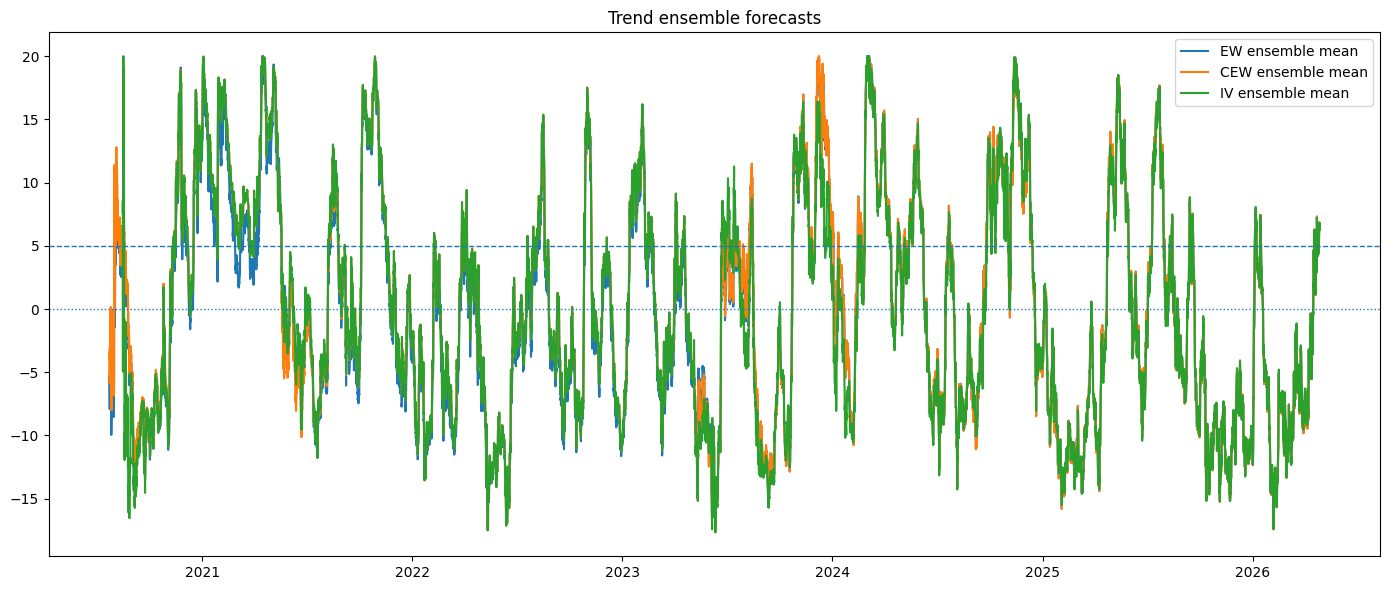

In [13]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(ew_ensemble.index, ew_ensemble["ew_ensemble_mean"], label="EW ensemble mean")
ax.plot(cew_ensemble.index, cew_ensemble["cew_ensemble_mean"], label="CEW ensemble mean")
ax.plot(iv_ensemble.index, iv_ensemble["iv_ensemble_mean"], label="IV ensemble mean")
ax.axhline(5, linestyle="--", linewidth=1)
ax.axhline(0, linestyle=":", linewidth=1)
ax.set_title("Trend ensemble forecasts")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "trend_ensemble_forecasts.png", dpi=150)
plt.show()


## Part 8 — Breadth, Volume, and DOGE Leader Features


In [14]:
def rolling_sum_return(r: pd.Series, bars: int) -> pd.Series:
    return (1.0 + r).rolling(bars, min_periods=max(3, bars // 3)).apply(np.prod, raw=True) - 1.0


def rolling_zscore(x: pd.Series, bars: int) -> pd.Series:
    mean = x.rolling(bars, min_periods=max(10, bars // 3)).mean()
    std = x.rolling(bars, min_periods=max(10, bars // 3)).std()
    return (x - mean) / std.replace(0, np.nan)


def build_confirmation_features(
    asset_returns: pd.DataFrame,
    close_panel: pd.DataFrame,
    quote_volume_panel: pd.DataFrame,
    taker_buy_ratio_panel: pd.DataFrame,
    basket_weights: pd.DataFrame,
    signal_index_returns: pd.Series,
) -> pd.DataFrame:
    idx = signal_index_returns.index
    out = pd.DataFrame(index=idx)

    aligned_returns = asset_returns.reindex(idx)
    aligned_close = close_panel.reindex(idx)

    for days in [1, 3, 7, 14, 30]:
        bars = days * BARS_PER_DAY
        trailing = (1.0 + aligned_returns).rolling(bars, min_periods=max(3, bars // 3)).apply(np.prod, raw=True) - 1.0
        denom = trailing.notna().sum(axis=1).replace(0, np.nan)
        out[f"breadth_pct_positive_{days}d"] = (trailing > 0).sum(axis=1) / denom
        out[f"xs_dispersion_{days}d"] = trailing.std(axis=1)

    for days in [30, 90]:
        bars = days * BARS_PER_DAY
        ma = aligned_close.rolling(bars, min_periods=max(10, bars // 3)).mean()
        denom = aligned_close.notna().sum(axis=1).replace(0, np.nan)
        out[f"breadth_pct_above_ma_{days}d"] = (aligned_close > ma).sum(axis=1) / denom

    w = basket_weights.reindex(idx).fillna(0.0)
    qv = quote_volume_panel.reindex(idx)
    tbr = taker_buy_ratio_panel.reindex(idx)

    basket_qv = (qv * w).sum(axis=1, min_count=1)
    basket_tbr = (tbr * w).sum(axis=1, min_count=1)

    out["basket_quote_volume"] = basket_qv
    out["basket_taker_buy_ratio"] = basket_tbr

    for days in [7, 30, 60]:
        bars = days * BARS_PER_DAY
        out[f"basket_qv_z_{days}d"] = rolling_zscore(np.log1p(basket_qv), bars)
        out[f"basket_taker_buy_ratio_z_{days}d"] = rolling_zscore(basket_tbr, bars)

    # DOGE leader
    if DOGE_SYMBOL in aligned_returns.columns:
        doge_r = aligned_returns[DOGE_SYMBOL]
        doge_price = aligned_close[DOGE_SYMBOL]
        basket_r = signal_index_returns.reindex(idx)

        out["doge_ret_7d_minus_basket"] = rolling_sum_return(doge_r, 7 * BARS_PER_DAY) - rolling_sum_return(basket_r, 7 * BARS_PER_DAY)
        out["doge_ret_30d_minus_basket"] = rolling_sum_return(doge_r, 30 * BARS_PER_DAY) - rolling_sum_return(basket_r, 30 * BARS_PER_DAY)
        out["doge_above_30d_ma"] = (doge_price > doge_price.rolling(30 * BARS_PER_DAY, min_periods=10 * BARS_PER_DAY).mean()).astype(float)
        out["doge_trend"] = ewma_forecast(doge_price.dropna(), 16, 64).reindex(idx)
        out["doge_trend_positive"] = (out["doge_trend"] > 0).astype(float)

    return out.replace([np.inf, -np.inf], np.nan)


confirm_ew = build_confirmation_features(
    simple_returns,
    close_panel,
    quote_volume_panel,
    taker_buy_ratio_panel,
    cew_weights,
    index_returns["equal_weight"],
)

confirm_ew.to_csv(OUT_DIR / "confirmation_features_ew_signal.csv")
display(confirm_ew.tail())


,breadth_pct_positive_1d,xs_dispersion_1d,breadth_pct_positive_3d,xs_dispersion_3d,breadth_pct_positive_7d,xs_dispersion_7d,breadth_pct_positive_14d,xs_dispersion_14d,breadth_pct_positive_30d,xs_dispersion_30d,breadth_pct_above_ma_30d,breadth_pct_above_ma_90d,basket_quote_volume,basket_taker_buy_ratio,basket_qv_z_7d,basket_taker_buy_ratio_z_7d,basket_qv_z_30d,basket_taker_buy_ratio_z_30d,basket_qv_z_60d,basket_taker_buy_ratio_z_60d,doge_ret_7d_minus_basket,doge_ret_30d_minus_basket,doge_above_30d_ma,doge_trend,doge_trend_positive
timestamp,,,,,,,,,,,,,,,,,,,,,,,,,
2026-04-26 04:00:00+00:00,0.714286,0.009391,0.857143,0.013731,0.857143,0.097596,0.857143,0.120334,0.857143,0.105326,0.857143,0.857143,"15,924,182.201390",0.503556,-0.544706,0.612194,-0.509883,0.527228,-0.674666,0.525129,0.004878,-0.044450,1.000000,2.759666,1.000000
2026-04-26 08:00:00+00:00,1.000000,0.014529,1.000000,0.023686,0.857143,0.102117,0.857143,0.131948,1.000000,0.123156,0.857143,0.857143,"15,639,006.467302",0.517611,-0.577153,1.198167,-0.539766,1.110392,-0.708323,1.135698,0.003357,-0.064707,1.000000,2.875306,1.000000
2026-04-26 12:00:00+00:00,1.000000,0.015596,0.714286,0.019730,0.714286,0.095056,0.857143,0.128117,1.000000,0.117880,0.857143,0.857143,"18,658,279.047919",0.497537,-0.065561,0.322096,-0.168523,0.250321,-0.356667,0.267732,0.015018,-0.063909,1.000000,3.112228,1.000000
2026-04-26 16:00:00+00:00,1.000000,0.024328,1.000000,0.027815,0.857143,0.108957,0.857143,0.137888,1.000000,0.126789,0.857143,0.857143,"15,123,472.598608",0.496776,-0.617911,0.262343,-0.604264,0.220191,-0.767736,0.236376,0.004075,-0.066143,1.000000,3.219074,1.000000
2026-04-26 20:00:00+00:00,0.857143,0.018963,0.714286,0.023777,0.857143,0.109054,0.857143,0.141989,1.000000,0.128494,0.857143,0.857143,"17,819,275.571187",0.489279,-0.139628,-0.126769,-0.271050,-0.104071,-0.437899,-0.091943,-0.003574,-0.069367,1.000000,3.315216,1.000000


## Part 9 — Backtest Engine

The main strategy is long/flat:

```text
if forecast > threshold and filters pass:
    exposure = vol_targeted long
else:
    exposure = flat
```

We apply a one-bar delay to avoid lookahead.


In [15]:
def vol_target_scale(r: pd.Series, target_vol: float, lookback_bars: int, max_gross: float) -> pd.Series:
    ann_vol = r.shift(1).rolling(lookback_bars, min_periods=max(20, lookback_bars // 3)).std() * math.sqrt(BARS_PER_YEAR)
    scale = target_vol / ann_vol.replace(0, np.nan)
    return scale.clip(upper=max_gross)


def make_long_flat_signal(forecast: pd.Series, threshold: float, exit_threshold: float = 0.0) -> pd.Series:
    state = []
    in_market = False

    for x in forecast:
        if not in_market and x > threshold:
            in_market = True
        elif in_market and x < exit_threshold:
            in_market = False
        state.append(1.0 if in_market else 0.0)

    return pd.Series(state, index=forecast.index)


def apply_filters(
    base_signal: pd.Series,
    confirm: pd.DataFrame,
    breadth_threshold: float | None = None,
    volume_z_threshold: float | None = None,
    doge_mode: str = "none",
) -> pd.Series:
    sig = base_signal.copy().astype(float)

    if breadth_threshold is not None:
        breadth_ok = confirm["breadth_pct_positive_7d"] > breadth_threshold
        sig = sig * breadth_ok.reindex(sig.index).fillna(False).astype(float)

    if volume_z_threshold is not None:
        volume_ok = confirm["basket_qv_z_7d"] > volume_z_threshold
        sig = sig * volume_ok.reindex(sig.index).fillna(False).astype(float)

    if doge_mode == "doge_trend_positive":
        doge_ok = confirm["doge_trend_positive"] > 0
        sig = sig * doge_ok.reindex(sig.index).fillna(False).astype(float)
    elif doge_mode == "doge_above_30d_ma":
        doge_ok = confirm["doge_above_30d_ma"] > 0
        sig = sig * doge_ok.reindex(sig.index).fillna(False).astype(float)
    elif doge_mode == "doge_leads_basket_7d":
        doge_ok = confirm["doge_ret_7d_minus_basket"] > 0
        sig = sig * doge_ok.reindex(sig.index).fillna(False).astype(float)
    elif doge_mode == "none":
        pass
    else:
        raise ValueError(f"Unknown doge_mode={doge_mode}")

    return sig


def backtest_index_signal(
    execution_returns: pd.Series,
    forecast: pd.Series,
    threshold: float,
    confirm: pd.DataFrame | None = None,
    breadth_threshold: float | None = None,
    volume_z_threshold: float | None = None,
    doge_mode: str = "none",
    target_vol: float = TARGET_VOL,
    cost_bps: float = BASE_COST_BPS,
    name: str = "strategy",
) -> pd.DataFrame:
    base_signal = make_long_flat_signal(forecast, threshold=threshold, exit_threshold=0.0)

    if confirm is not None:
        base_signal = apply_filters(
            base_signal,
            confirm,
            breadth_threshold=breadth_threshold,
            volume_z_threshold=volume_z_threshold,
            doge_mode=doge_mode,
        )

    scale = vol_target_scale(execution_returns, target_vol, VOL_LOOKBACK_BARS, MAX_GROSS_EXPOSURE)
    signal_exposure = (base_signal * scale).rename("signal_exposure")

    df = pd.concat([execution_returns.rename("execution_return"), signal_exposure], axis=1).dropna()

    # one-bar execution delay
    exposure = df["signal_exposure"].shift(1).fillna(0.0).clip(0, MAX_GROSS_EXPOSURE)
    turnover = exposure.diff().abs().fillna(exposure.abs())
    cost = turnover * (cost_bps / 10_000.0)
    strategy_return = exposure * df["execution_return"] - cost

    out = pd.DataFrame({
        "execution_return": df["execution_return"],
        "signal_exposure": df["signal_exposure"],
        "exposure": exposure,
        "turnover": turnover,
        "cost": cost,
        "strategy_return": strategy_return,
    })

    out["equity"] = equity_from_returns(out["strategy_return"])
    out["buyhold_equity"] = equity_from_returns(out["execution_return"])
    out["strategy_name"] = name
    return out


def strategy_stats(bt: pd.DataFrame, name: str) -> dict:
    s = perf_stats(bt["strategy_return"], name)
    s.update({
        "avg_exposure": bt["exposure"].mean(),
        "ann_turnover": bt["turnover"].mean() * BARS_PER_YEAR,
        "total_cost": bt["cost"].sum(),
        "pct_time_in_market": (bt["exposure"] > 0).mean(),
    })
    return s


## Part 10 — Experiment 1: Signal Index vs Execution Index

Test:

```text
A. EW signal -> EW execution
B. EW signal -> capped-EW execution
C. EW signal -> IV execution
D. IV signal -> IV execution
E. IV signal -> EW execution
```

This directly tests whether equal-weight is better for signal generation while risk is controlled separately.


In [16]:
def run_signal_execution_experiment():
    experiments = []

    configs = [
        {
            "name": "EW_signal_EW_execution",
            "forecast": ew_ensemble["ew_ensemble_mean"],
            "execution": index_returns["equal_weight"],
            "confirm": confirm_ew,
        },
        {
            "name": "EW_signal_CEW_execution",
            "forecast": ew_ensemble["ew_ensemble_mean"],
            "execution": index_returns["capped_equal_weight"],
            "confirm": confirm_ew,
        },
        {
            "name": "EW_signal_IV_execution",
            "forecast": ew_ensemble["ew_ensemble_mean"],
            "execution": index_returns["inverse_vol"],
            "confirm": confirm_ew,
        },
        {
            "name": "IV_signal_IV_execution",
            "forecast": iv_ensemble["iv_ensemble_mean"],
            "execution": index_returns["inverse_vol"],
            "confirm": confirm_ew,
        },
        {
            "name": "IV_signal_EW_execution",
            "forecast": iv_ensemble["iv_ensemble_mean"],
            "execution": index_returns["equal_weight"],
            "confirm": confirm_ew,
        },
    ]

    bts = {}

    for cfg in configs:
        bt = backtest_index_signal(
            execution_returns=cfg["execution"],
            forecast=cfg["forecast"],
            threshold=5.0,
            confirm=None,
            target_vol=TARGET_VOL,
            cost_bps=BASE_COST_BPS,
            name=cfg["name"],
        )
        bts[cfg["name"]] = bt
        st = strategy_stats(bt, cfg["name"])
        st["signal_execution_config"] = cfg["name"]
        experiments.append(st)

    return pd.DataFrame(experiments), bts


sig_exec_results, sig_exec_bts = run_signal_execution_experiment()
sig_exec_results.to_csv(OUT_DIR / "signal_execution_experiment.csv", index=False)
display(sig_exec_results.sort_values("sharpe_like", ascending=False))


,name,start,end,bars,years,total_return,cagr,ann_mean,ann_vol,sharpe_like,max_drawdown,calmar,hit_rate,best_bar,worst_bar,skew,kurtosis,avg_exposure,ann_turnover,total_cost,pct_time_in_market,signal_execution_config
0,EW_signal_EW_execution,2020-08-06 12:00:00+00:00,2026-04-26 20:00:00+00:00,12537,5.724658,18.920464,0.686419,0.599543,0.397190,1.509462,-0.389676,1.761513,0.198373,0.251256,-0.068025,5.058976,109.455546,0.178131,6.247817,0.035767,0.388131,EW_signal_EW_execution
4,IV_signal_EW_execution,2020-08-09 12:00:00+00:00,2026-04-26 20:00:00+00:00,12519,5.716438,15.913578,0.640062,0.572669,0.399662,1.432883,-0.434229,1.474020,0.198418,0.251256,-0.071356,4.924595,107.359274,0.177512,6.618858,0.037836,0.387731,IV_signal_EW_execution
1,EW_signal_CEW_execution,2020-08-06 12:00:00+00:00,2026-04-26 20:00:00+00:00,12537,5.724658,10.467320,0.531334,0.490760,0.363550,1.349908,-0.389676,1.363528,0.198293,0.251244,-0.062733,4.970779,121.885683,0.266458,7.818931,0.044761,0.388131,EW_signal_CEW_execution
2,EW_signal_IV_execution,2020-08-29 12:00:00+00:00,2026-04-26 20:00:00+00:00,12399,5.661644,8.303534,0.482824,0.457233,0.359937,1.270315,-0.406221,1.188574,0.195822,0.251244,-0.065377,5.200771,128.410036,0.251893,7.455223,0.042209,0.383418,EW_signal_IV_execution
3,IV_signal_IV_execution,2020-08-29 12:00:00+00:00,2026-04-26 20:00:00+00:00,12399,5.661644,6.774681,0.436543,0.426631,0.362958,1.175427,-0.485150,0.899811,0.199210,0.251244,-0.071358,5.019304,124.825257,0.262755,8.122356,0.045986,0.390596,IV_signal_IV_execution


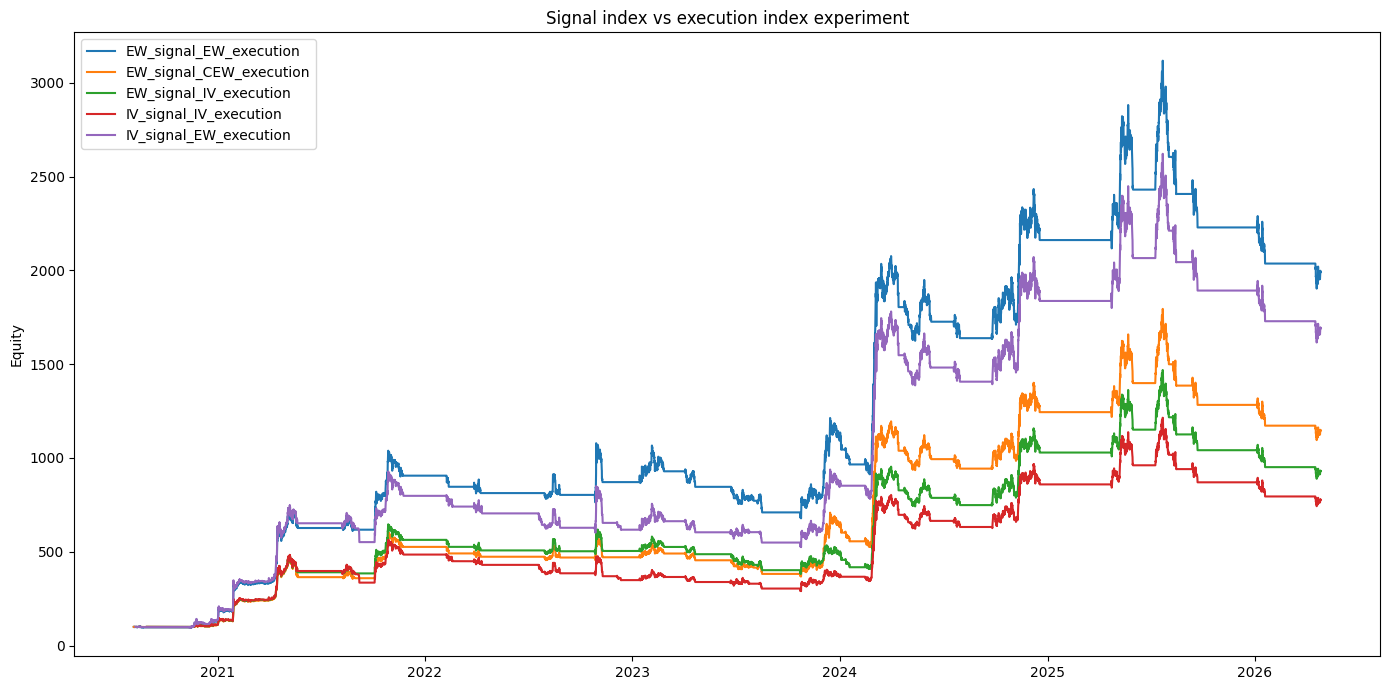

In [17]:
fig, ax = plt.subplots(figsize=(14, 7))
for name, bt in sig_exec_bts.items():
    ax.plot(bt["equity"], label=name)
ax.set_title("Signal index vs execution index experiment")
ax.set_ylabel("Equity")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "signal_execution_equity.png", dpi=150)
plt.show()


## Part 11 — Experiment 2: Trend Ensemble vs EWMA-Only

Compare:

1. old EWMA-only style
2. ensemble mean
3. ensemble vote forecast


In [18]:
def old_ewma_only_forecast(index_return: pd.Series, name: str) -> pd.Series:
    price = equity_from_returns(index_return.dropna())
    parts = []
    for fast, slow in [(16, 64), (32, 128), (64, 256)]:
        parts.append(ewma_forecast(price, fast, slow))
    return pd.concat(parts, axis=1).mean(axis=1).rename(name)


ew_old_forecast = old_ewma_only_forecast(index_returns["equal_weight"], "ew_old_ewma")
ew_ensemble_mean = ew_ensemble["ew_ensemble_mean"]
ew_ensemble_vote = ew_ensemble["ew_ensemble_vote_forecast"]

forecast_variants = {
    "old_ewma_only": ew_old_forecast,
    "ensemble_mean": ew_ensemble_mean,
    "ensemble_vote": ew_ensemble_vote,
}

forecast_rows = []
forecast_bts = {}

for name, fc in forecast_variants.items():
    bt = backtest_index_signal(
        execution_returns=index_returns["capped_equal_weight"],
        forecast=fc,
        threshold=5.0,
        confirm=None,
        target_vol=TARGET_VOL,
        cost_bps=BASE_COST_BPS,
        name=f"forecast_{name}",
    )
    forecast_bts[name] = bt
    st = strategy_stats(bt, f"forecast_{name}")
    st["forecast_variant"] = name
    forecast_rows.append(st)

forecast_variant_results = pd.DataFrame(forecast_rows).sort_values("sharpe_like", ascending=False)
forecast_variant_results.to_csv(OUT_DIR / "forecast_variant_results.csv", index=False)
display(forecast_variant_results)


,name,start,end,bars,years,total_return,cagr,ann_mean,ann_vol,sharpe_like,max_drawdown,calmar,hit_rate,best_bar,worst_bar,skew,kurtosis,avg_exposure,ann_turnover,total_cost,pct_time_in_market,forecast_variant
0,forecast_old_ewma_only,2020-08-06 12:00:00+00:00,2026-04-26 20:00:00+00:00,12537,5.724658,10.618032,0.534831,0.490265,0.355784,1.377982,-0.403102,1.326787,0.182659,0.251244,-0.062733,5.249752,132.413685,0.249617,7.206663,0.041256,0.357342,old_ewma_only
1,forecast_ensemble_mean,2020-08-06 12:00:00+00:00,2026-04-26 20:00:00+00:00,12537,5.724658,10.467320,0.531334,0.490760,0.363550,1.349908,-0.389676,1.363528,0.198293,0.251244,-0.062733,4.970779,121.885683,0.266458,7.818931,0.044761,0.388131,ensemble_mean
2,forecast_ensemble_vote,2020-08-06 12:00:00+00:00,2026-04-26 20:00:00+00:00,12537,5.724658,10.477403,0.531569,0.494197,0.372467,1.326820,-0.556876,0.954555,0.216160,0.251244,-0.071358,4.616283,110.848995,0.296133,18.687018,0.106977,0.424583,ensemble_vote


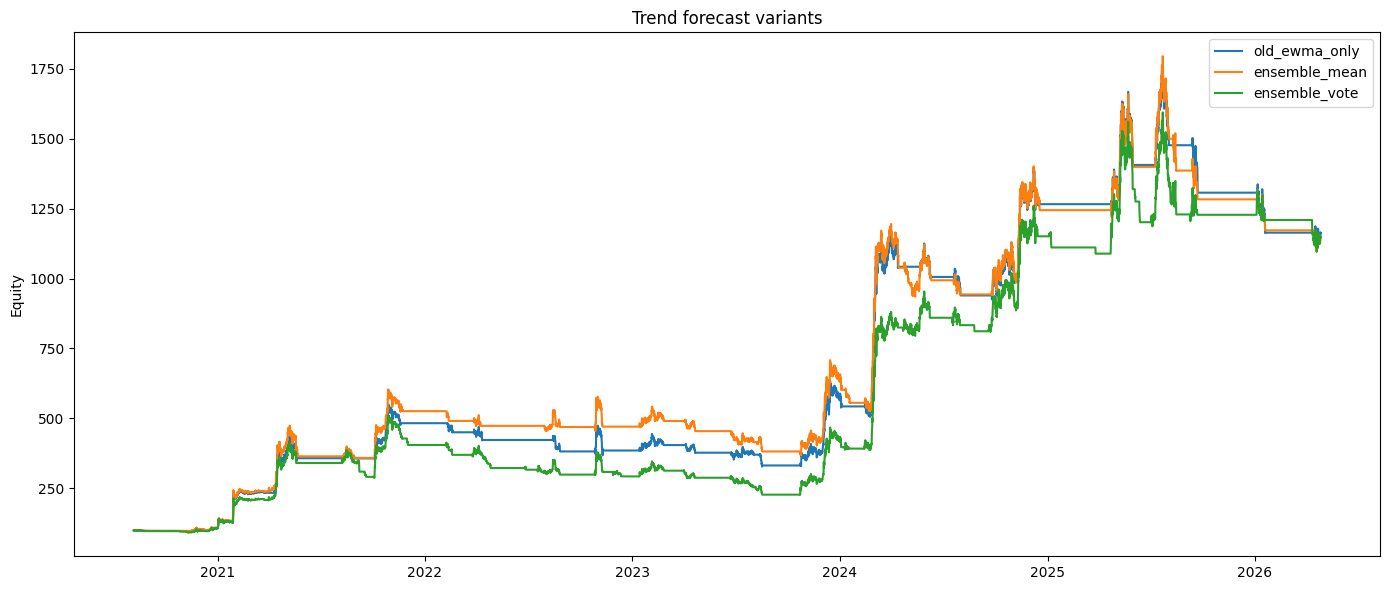

In [19]:
fig, ax = plt.subplots(figsize=(14, 6))
for name, bt in forecast_bts.items():
    ax.plot(bt["equity"], label=name)
ax.set_title("Trend forecast variants")
ax.set_ylabel("Equity")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "forecast_variant_equity.png", dpi=150)
plt.show()


## Part 12 — Experiment 3: Breadth, Volume, and DOGE Filters

We test whether filters improve trend quality.

A good improvement should:

- reduce drawdown
- improve Sharpe/Calmar
- not destroy CAGR
- not only work with one exact threshold


In [20]:
filter_rows = []
filter_bts = {}

base_forecast = ew_ensemble["ew_ensemble_mean"]
base_execution = index_returns["capped_equal_weight"]

for breadth_th in [None] + BREADTH_THRESHOLDS:
    for vol_th in [None] + VOLUME_Z_THRESHOLDS:
        for doge_mode in DOGE_FILTER_MODES:
            name = f"breadth_{breadth_th}_vol_{vol_th}_doge_{doge_mode}"

            bt = backtest_index_signal(
                execution_returns=base_execution,
                forecast=base_forecast,
                threshold=5.0,
                confirm=confirm_ew,
                breadth_threshold=breadth_th,
                volume_z_threshold=vol_th,
                doge_mode=doge_mode,
                target_vol=TARGET_VOL,
                cost_bps=BASE_COST_BPS,
                name=name,
            )

            filter_bts[name] = bt
            st = strategy_stats(bt, name)
            st.update({
                "breadth_threshold": breadth_th,
                "volume_z_threshold": vol_th,
                "doge_mode": doge_mode,
            })
            filter_rows.append(st)

filter_results = pd.DataFrame(filter_rows).sort_values("sharpe_like", ascending=False)
filter_results.to_csv(OUT_DIR / "filter_experiment_results.csv", index=False)

display(filter_results.head(30))


,name,start,end,bars,years,total_return,cagr,ann_mean,ann_vol,sharpe_like,max_drawdown,calmar,hit_rate,best_bar,worst_bar,skew,kurtosis,avg_exposure,ann_turnover,total_cost,pct_time_in_market,breadth_threshold,volume_z_threshold,doge_mode
25,breadth_0.4_vol_-0.5_doge_doge_trend_positive,2020-08-06 12:00:00+00:00,2026-04-26 20:00:00+00:00,12537,5.724658,11.670708,0.558262,0.487070,0.299722,1.625071,-0.371356,1.503307,0.085427,0.251244,-0.062733,8.630904,256.071080,0.120316,95.256502,0.545311,0.165909,0.400000,-0.500000,doge_trend_positive
45,breadth_0.5_vol_-0.5_doge_doge_trend_positive,2020-08-06 12:00:00+00:00,2026-04-26 20:00:00+00:00,12537,5.724658,10.806096,0.539142,0.473349,0.295087,1.604096,-0.338635,1.592104,0.079445,0.251244,-0.062733,9.016215,272.194642,0.111817,89.281011,0.511103,0.154822,0.500000,-0.500000,doge_trend_positive
5,breadth_None_vol_-0.5_doge_doge_trend_positive,2020-08-06 12:00:00+00:00,2026-04-26 20:00:00+00:00,12537,5.724658,11.864256,0.562394,0.493342,0.311562,1.583446,-0.390851,1.438897,0.100423,0.251244,-0.062733,7.661774,219.937963,0.138438,115.392844,0.660585,0.194066,NaN,-0.500000,doge_trend_positive
1,breadth_None_vol_None_doge_doge_trend_positive,2020-08-06 12:00:00+00:00,2026-04-26 20:00:00+00:00,12537,5.724658,13.764607,0.600454,0.525299,0.335922,1.563754,-0.344920,1.740848,0.148839,0.251244,-0.062733,6.115530,163.340489,0.205259,13.656490,0.078179,0.289543,NaN,NaN,doge_trend_positive
41,breadth_0.5_vol_None_doge_doge_trend_positive,2020-08-06 12:00:00+00:00,2026-04-26 20:00:00+00:00,12537,5.724658,11.183768,0.547631,0.483987,0.312024,1.551119,-0.302366,1.811156,0.109516,0.251244,-0.062733,7.646129,218.611284,0.153065,40.907493,0.234181,0.213687,0.500000,NaN,doge_trend_positive
85,breadth_0.7_vol_-0.5_doge_doge_trend_positive,2020-08-06 12:00:00+00:00,2026-04-26 20:00:00+00:00,12537,5.724658,9.189347,0.500051,0.446235,0.290362,1.536824,-0.330548,1.512795,0.072585,0.251244,-0.062733,9.460986,290.322406,0.103926,83.702855,0.479170,0.142618,0.700000,-0.500000,doge_trend_positive
21,breadth_0.4_vol_None_doge_doge_trend_positive,2020-08-06 12:00:00+00:00,2026-04-26 20:00:00+00:00,12537,5.724658,11.352802,0.551361,0.488507,0.318729,1.532672,-0.297312,1.854487,0.118609,0.251244,-0.062733,7.181403,201.072080,0.166368,35.544039,0.203477,0.231634,0.400000,NaN,doge_trend_positive
46,breadth_0.5_vol_-0.5_doge_doge_above_30d_ma,2020-08-06 12:00:00+00:00,2026-04-26 20:00:00+00:00,12537,5.724658,9.464061,0.507038,0.452285,0.295137,1.532457,-0.333042,1.522447,0.079126,0.251244,-0.062733,8.989293,271.929598,0.111580,91.746079,0.525215,0.154662,0.500000,-0.500000,doge_above_30d_ma
44,breadth_0.5_vol_-0.5_doge_none,2020-08-06 12:00:00+00:00,2026-04-26 20:00:00+00:00,12537,5.724658,9.674067,0.512278,0.456872,0.298946,1.528277,-0.382276,1.340075,0.083832,0.251244,-0.062733,8.733019,259.190399,0.116688,98.400512,0.563309,0.163835,0.500000,-0.500000,none
24,breadth_0.4_vol_-0.5_doge_none,2020-08-06 12:00:00+00:00,2026-04-26 20:00:00+00:00,12537,5.724658,9.803809,0.515473,0.460666,0.304538,1.512670,-0.435808,1.182798,0.091489,0.251244,-0.062733,8.283904,240.997412,0.127729,109.588064,0.627354,0.178512,0.400000,-0.500000,none


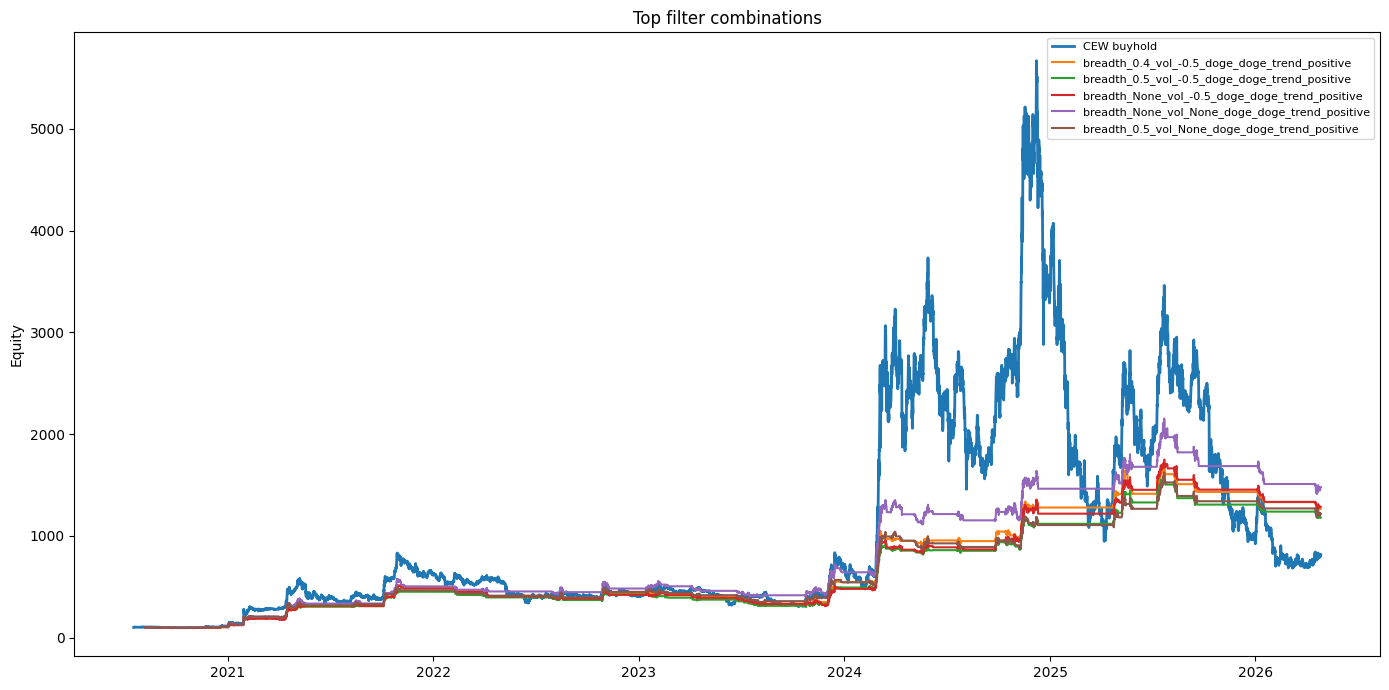

In [21]:
top_filter_names = filter_results.head(5)["name"].tolist()

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(equity_from_returns(base_execution.dropna()), label="CEW buyhold", linewidth=2)
for name in top_filter_names:
    ax.plot(filter_bts[name]["equity"], label=name)
ax.set_title("Top filter combinations")
ax.set_ylabel("Equity")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / "top_filter_combination_equity.png", dpi=150)
plt.show()


## Part 13 — Experiment 4: Component-Level Top-N Trend

Instead of trading the whole basket, hold only the top-N positive-trend coins.

This addresses the idea that meme returns are concentrated.


In [22]:
def make_component_trend_forecasts(close_panel: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(index=close_panel.index)

    for symbol in close_panel.columns:
        price = close_panel[symbol].dropna()
        if price.empty:
            continue

        parts = []
        for fast, slow in EWMA_SPEEDS:
            parts.append(ewma_forecast(price, fast, slow))
        for d in TSMOM_DAYS:
            parts.append(tsmom_forecast(price, d))
        for d in DONCHIAN_DAYS:
            parts.append(donchian_forecast(price, d))

        out[symbol] = pd.concat(parts, axis=1).mean(axis=1)

    return out.reindex(close_panel.index)


component_forecasts = make_component_trend_forecasts(close_panel)
component_forecasts.to_csv(OUT_DIR / "component_trend_ensemble.csv")
display(component_forecasts.tail())


,1000BONKUSDT,1000PEPEUSDT,1000SHIBUSDT,DOGEUSDT,PENGUUSDT,POPCATUSDT,WIFUSDT
timestamp,,,,,,,
2026-04-26 04:00:00+00:00,1.500628,3.179763,2.552231,2.626262,10.547244,5.801322,-7.107230
2026-04-26 08:00:00+00:00,1.988316,4.036067,2.891245,3.126630,11.409773,6.492978,-6.820408
2026-04-26 12:00:00+00:00,1.116741,3.648764,2.214031,2.847102,9.966735,5.994808,-7.500261
2026-04-26 16:00:00+00:00,1.282061,3.636692,2.454481,3.208023,11.726573,6.377371,-7.344759
2026-04-26 20:00:00+00:00,1.445858,3.526425,2.686248,3.357222,11.685829,7.054486,-7.320065


In [23]:
def top_n_component_weights(
    forecasts: pd.DataFrame,
    eligible: pd.DataFrame,
    top_n: int,
    base_weights: pd.DataFrame,
    min_forecast: float,
) -> pd.DataFrame:
    out = pd.DataFrame(0.0, index=forecasts.index, columns=forecasts.columns)

    for ts in forecasts.index:
        if ts not in eligible.index:
            continue

        row = forecasts.loc[ts]
        elig = eligible.loc[ts].reindex(forecasts.columns).fillna(False)
        valid = row[elig & row.notna()]
        valid = valid[valid > min_forecast]

        if valid.empty:
            continue

        selected = valid.sort_values(ascending=False).head(top_n).index
        bw = base_weights.reindex(forecasts.index).loc[ts, selected].fillna(0.0)

        if bw.sum() <= 0:
            w = pd.Series(1.0 / len(selected), index=selected)
        else:
            w = bw / bw.sum()

        out.loc[ts, selected] = w

    return out


def backtest_component_weights(
    asset_returns: pd.DataFrame,
    target_weights: pd.DataFrame,
    target_vol: float,
    cost_bps: float,
    name: str,
) -> pd.DataFrame:
    r, w_signal = asset_returns.align(target_weights, join="inner", axis=0)
    w_signal = w_signal.fillna(0.0)

    # Component weights are long-only. Then apply portfolio vol scaling from realized strategy returns estimate.
    pre_ret_signal = (w_signal * r.fillna(0.0)).sum(axis=1)
    scale = vol_target_scale(pre_ret_signal, target_vol, VOL_LOOKBACK_BARS, MAX_GROSS_EXPOSURE).reindex(w_signal.index).fillna(0.0)
    scaled_signal = w_signal.mul(scale, axis=0)

    # one-bar delay
    w = scaled_signal.shift(1).fillna(0.0)
    ret = (w * r.fillna(0.0)).sum(axis=1)

    turnover = w.diff().abs().sum(axis=1).fillna(w.abs().sum(axis=1))
    cost = turnover * (cost_bps / 10_000.0)
    strategy_return = ret - cost

    out = pd.DataFrame({
        "strategy_return": strategy_return,
        "gross_exposure": w.abs().sum(axis=1),
        "net_exposure": w.sum(axis=1),
        "turnover": turnover,
        "cost": cost,
    })

    out["equity"] = equity_from_returns(out["strategy_return"])
    out["strategy_name"] = name
    return out


component_rows = []
component_bts = {}

for top_n in TOP_N_LIST:
    weights = top_n_component_weights(
        component_forecasts,
        eligible,
        top_n=top_n,
        base_weights=cew_weights,
        min_forecast=5.0,
    )

    bt = backtest_component_weights(
        simple_returns,
        weights,
        target_vol=TARGET_VOL,
        cost_bps=BASE_COST_BPS,
        name=f"component_top_{top_n}",
    )

    component_bts[f"component_top_{top_n}"] = bt
    st = perf_stats(bt["strategy_return"], f"component_top_{top_n}")
    st.update({
        "top_n": top_n,
        "avg_gross_exposure": bt["gross_exposure"].mean(),
        "ann_turnover": bt["turnover"].mean() * BARS_PER_YEAR,
        "total_cost": bt["cost"].sum(),
    })
    component_rows.append(st)

component_results = pd.DataFrame(component_rows).sort_values("sharpe_like", ascending=False)
component_results.to_csv(OUT_DIR / "component_top_n_results.csv", index=False)
display(component_results)


,name,start,end,bars,years,total_return,cagr,ann_mean,ann_vol,sharpe_like,max_drawdown,calmar,hit_rate,best_bar,worst_bar,skew,kurtosis,top_n,avg_gross_exposure,ann_turnover,total_cost
0,component_top_2,2020-07-10 08:00:00+00:00,2026-04-26 20:00:00+00:00,12700,5.799087,36.330183,0.866756,0.757524,0.524211,1.445076,-0.637350,1.359937,0.160945,0.256875,-0.117251,4.646460,84.241482,2,0.161522,63.004340,0.365368
1,component_top_3,2020-07-10 08:00:00+00:00,2026-04-26 20:00:00+00:00,12700,5.799087,34.874298,0.853994,0.749526,0.522022,1.435813,-0.632889,1.349359,0.161024,0.256875,-0.117251,4.694555,85.397305,3,0.165666,69.812995,0.404852
3,component_top_5,2020-07-10 08:00:00+00:00,2026-04-26 20:00:00+00:00,12700,5.799087,27.762049,0.784680,0.710532,0.520249,1.365754,-0.632889,1.239839,0.161102,0.256875,-0.117251,4.700264,86.432245,5,0.167534,71.752102,0.416097
2,component_top_4,2020-07-10 08:00:00+00:00,2026-04-26 20:00:00+00:00,12700,5.799087,24.889965,0.752596,0.692150,0.519760,1.331674,-0.632889,1.189144,0.160866,0.256875,-0.117251,4.696108,86.711215,4,0.166948,71.671604,0.415630


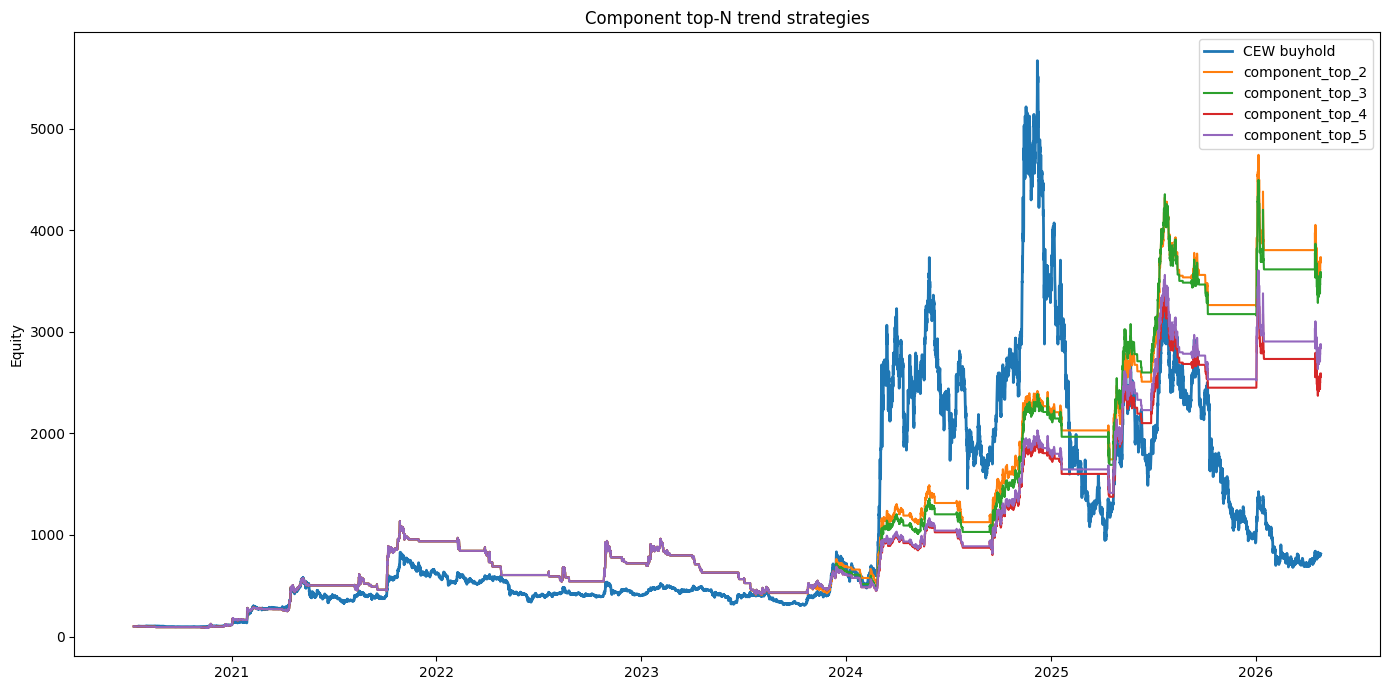

In [24]:
fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(equity_from_returns(index_returns["capped_equal_weight"].dropna()), label="CEW buyhold", linewidth=2)
for name, bt in component_bts.items():
    ax.plot(bt["equity"], label=name)
ax.set_title("Component top-N trend strategies")
ax.set_ylabel("Equity")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "component_top_n_equity.png", dpi=150)
plt.show()


## Part 14 — Robustness Grid

We test:

- entry threshold
- breadth threshold
- volume threshold
- DOGE filter

This helps detect overfitting.


In [25]:
robust_rows = []

for entry_th in ENTRY_THRESHOLDS:
    for breadth_th in [None, 0.5, 0.6]:
        for vol_th in [None, 0.0, 0.5]:
            for doge_mode in ["none", "doge_trend_positive", "doge_leads_basket_7d"]:
                name = f"entry_{entry_th}_breadth_{breadth_th}_vol_{vol_th}_doge_{doge_mode}"

                bt = backtest_index_signal(
                    execution_returns=base_execution,
                    forecast=base_forecast,
                    threshold=entry_th,
                    confirm=confirm_ew,
                    breadth_threshold=breadth_th,
                    volume_z_threshold=vol_th,
                    doge_mode=doge_mode,
                    target_vol=TARGET_VOL,
                    cost_bps=BASE_COST_BPS,
                    name=name,
                )

                st = strategy_stats(bt, name)
                st.update({
                    "entry_threshold": entry_th,
                    "breadth_threshold": breadth_th,
                    "volume_z_threshold": vol_th,
                    "doge_mode": doge_mode,
                })
                robust_rows.append(st)

robustness = pd.DataFrame(robust_rows).sort_values("sharpe_like", ascending=False)
robustness.to_csv(OUT_DIR / "robustness_grid.csv", index=False)
display(robustness.head(30))


,name,start,end,bars,years,total_return,cagr,ann_mean,ann_vol,sharpe_like,max_drawdown,calmar,hit_rate,best_bar,worst_bar,skew,kurtosis,avg_exposure,ann_turnover,total_cost,pct_time_in_market,entry_threshold,breadth_threshold,volume_z_threshold,doge_mode
118,entry_10_breadth_0.5_vol_None_doge_doge_trend_...,2020-08-06 12:00:00+00:00,2026-04-26 20:00:00+00:00,12537,5.724658,11.615861,0.557082,0.482472,0.286526,1.683867,-0.193687,2.876198,0.077132,0.251244,-0.062733,9.707222,303.929732,0.105763,28.494775,0.163123,0.149876,10.000000,0.500000,NaN,doge_trend_positive
117,entry_10_breadth_0.5_vol_None_doge_none,2020-08-06 12:00:00+00:00,2026-04-26 20:00:00+00:00,12537,5.724658,11.230938,0.548676,0.478056,0.290021,1.648348,-0.231656,2.368493,0.081918,0.251244,-0.062733,9.418943,290.322855,0.111460,32.660382,0.186970,0.159528,10.000000,0.500000,NaN,none
1,entry_0_breadth_None_vol_None_doge_doge_trend_...,2020-08-06 12:00:00+00:00,2026-04-26 20:00:00+00:00,12537,5.724658,18.490772,0.680007,0.579687,0.353150,1.641476,-0.316451,2.148857,0.171492,0.251244,-0.071358,5.496133,137.269707,0.239052,23.833637,0.136439,0.335327,0.000000,NaN,NaN,doge_trend_positive
10,entry_0_breadth_0.5_vol_None_doge_doge_trend_p...,2020-08-06 12:00:00+00:00,2026-04-26 20:00:00+00:00,12537,5.724658,14.626006,0.616385,0.531756,0.325686,1.632724,-0.321887,1.914911,0.128021,0.251244,-0.062733,6.985141,186.737282,0.181111,52.613408,0.301194,0.252373,0.000000,0.500000,NaN,doge_trend_positive
127,entry_10_breadth_0.6_vol_None_doge_doge_trend_...,2020-08-06 12:00:00+00:00,2026-04-26 20:00:00+00:00,12537,5.724658,10.492126,0.531912,0.465877,0.285493,1.631833,-0.193687,2.746248,0.075297,0.251244,-0.062733,9.809928,308.382270,0.104794,28.618478,0.163831,0.147244,10.000000,0.600000,NaN,doge_trend_positive
109,entry_10_breadth_None_vol_None_doge_doge_trend...,2020-08-06 12:00:00+00:00,2026-04-26 20:00:00+00:00,12537,5.724658,12.538320,0.576395,0.500997,0.307369,1.629955,-0.222759,2.587524,0.106804,0.251244,-0.062733,7.828277,230.406296,0.145166,8.952772,0.051252,0.208024,10.000000,NaN,NaN,doge_trend_positive
28,entry_2.5_breadth_None_vol_None_doge_doge_tren...,2020-08-06 12:00:00+00:00,2026-04-26 20:00:00+00:00,12537,5.724658,16.127163,0.642494,0.554534,0.345667,1.604246,-0.312280,2.057429,0.162080,0.251244,-0.071358,5.687804,147.615169,0.225209,16.056998,0.091921,0.315626,2.500000,NaN,NaN,doge_trend_positive
121,entry_10_breadth_0.5_vol_0.0_doge_doge_trend_p...,2020-08-06 12:00:00+00:00,2026-04-26 20:00:00+00:00,12537,5.724658,8.274756,0.475609,0.422764,0.264903,1.595921,-0.168113,2.829098,0.043790,0.251244,-0.062733,12.241604,414.750582,0.060609,57.008572,0.326355,0.085347,10.000000,0.500000,0.000000,doge_trend_positive
126,entry_10_breadth_0.6_vol_None_doge_none,2020-08-06 12:00:00+00:00,2026-04-26 20:00:00+00:00,12537,5.724658,10.063509,0.521774,0.460227,0.288977,1.592608,-0.231656,2.252364,0.079844,0.251244,-0.062733,9.518653,294.575674,0.110393,32.950987,0.188633,0.156656,10.000000,0.600000,NaN,none
37,entry_2.5_breadth_0.5_vol_None_doge_doge_trend...,2020-08-06 12:00:00+00:00,2026-04-26 20:00:00+00:00,12537,5.724658,12.705225,0.579773,0.506581,0.318513,1.590454,-0.308184,1.881252,0.120204,0.251244,-0.062733,7.235147,201.416044,0.169098,45.196693,0.258736,0.235383,2.500000,0.500000,NaN,doge_trend_positive


## Part 15 — P-Value Tests

We test strategy excess return against capped equal-weight buy-and-hold.


In [26]:
def strategy_pvalue_vs_buyhold(bt: pd.DataFrame, buyhold_returns: pd.Series, name: str) -> dict:
    bh = buyhold_returns.reindex(bt.index)
    excess = bt["strategy_return"] - bh

    hac = hac_mean_test(excess, maxlags=30 * BARS_PER_DAY)
    boot = block_bootstrap_mean_pvalue(
        excess,
        block_size=30 * BARS_PER_DAY,
        n_boot=1000,
        alternative="greater",
        random_state=42,
    )

    return {
        "strategy": name,
        "ann_excess_vs_buyhold": hac["mean"] * BARS_PER_YEAR if pd.notna(hac["mean"]) else np.nan,
        "hac_t": hac["t"],
        "hac_p_greater": hac["p_greater"],
        "hac_label": evidence_label(hac["p_greater"]),
        "bootstrap_p": boot["p"],
        "bootstrap_label": evidence_label(boot["p"]),
        "n": hac["n"],
    }


best_filter_name = filter_results.iloc[0]["name"]
best_filter_bt = filter_bts[best_filter_name]

best_component_name = component_results.iloc[0]["name"]
best_component_bt = component_bts[best_component_name]

pvalue_rows = [
    strategy_pvalue_vs_buyhold(best_filter_bt, index_returns["capped_equal_weight"], best_filter_name),
    strategy_pvalue_vs_buyhold(best_component_bt, index_returns["capped_equal_weight"], best_component_name),
]

# Add baseline old EWMA
old_bt = forecast_bts["old_ewma_only"]
pvalue_rows.append(strategy_pvalue_vs_buyhold(old_bt, index_returns["capped_equal_weight"], "old_ewma_only"))

pvalue_results = pd.DataFrame(pvalue_rows)
pvalue_results.to_csv(OUT_DIR / "pvalue_results.csv", index=False)
display(pvalue_results)


,strategy,ann_excess_vs_buyhold,hac_t,hac_p_greater,hac_label,bootstrap_p,bootstrap_label,n
0,breadth_0.4_vol_-0.5_doge_doge_trend_positive,-0.240148,-0.731411,0.767729,weak_evidence,0.806194,weak_evidence,12537
1,component_top_2,0.032702,0.111110,0.455765,weak_evidence,0.491508,weak_evidence,12657
2,old_ewma_only,-0.236953,-0.789500,0.785083,weak_evidence,0.813187,weak_evidence,12537


## Part 16 — Year-by-Year Robustness


,buyhold_capped_equal_weight,old_ewma_only,best_filter,best_component_top_n
timestamp,,,,
2020,0.147488,0.077434,0.036265,0.144038
2021,4.392851,3.483326,3.754201,7.198393
2022,-0.343936,-0.202115,-0.108751,-0.231684
2023,0.651391,0.471289,0.245425,-0.048313
2024,4.118275,1.231912,1.336941,2.211917
2025,-0.730757,0.032468,0.119628,0.481403
2026,-0.119214,-0.110901,-0.114447,0.143982


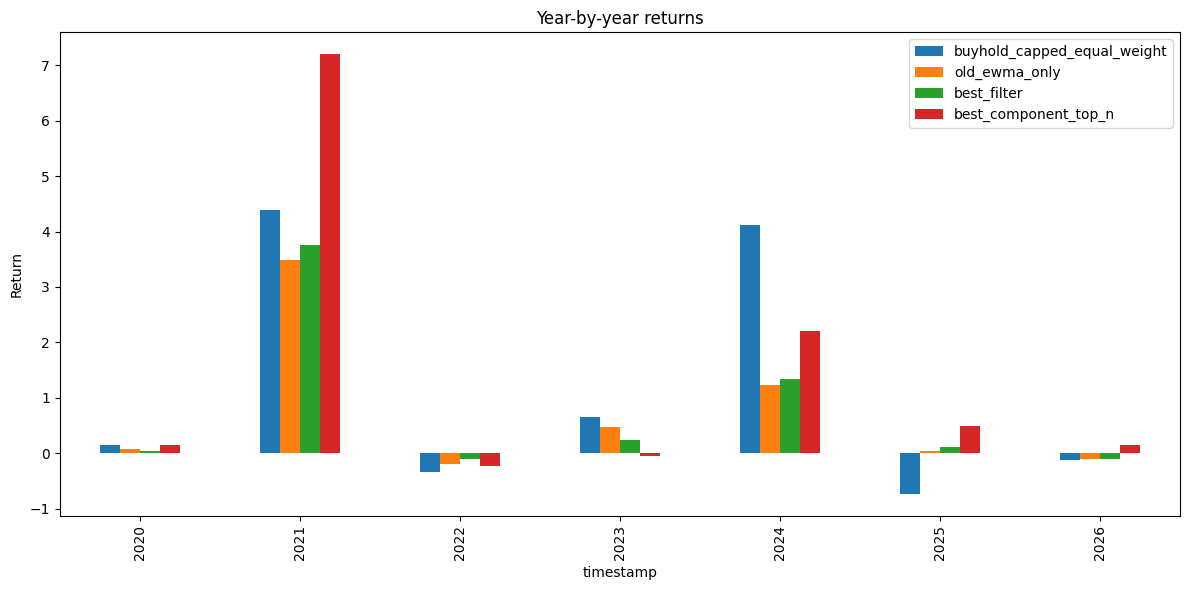

In [27]:
def yearly_returns(r: pd.Series) -> pd.Series:
    r = r.dropna()
    return (1.0 + r).groupby(r.index.year).prod() - 1


yearly = pd.DataFrame({
    "buyhold_capped_equal_weight": yearly_returns(index_returns["capped_equal_weight"]),
    "old_ewma_only": yearly_returns(old_bt["strategy_return"]),
    "best_filter": yearly_returns(best_filter_bt["strategy_return"]),
    "best_component_top_n": yearly_returns(best_component_bt["strategy_return"]),
})

yearly.to_csv(OUT_DIR / "yearly_returns.csv")
display(yearly)

fig, ax = plt.subplots(figsize=(12, 6))
yearly.plot(kind="bar", ax=ax)
ax.set_title("Year-by-year returns")
ax.set_ylabel("Return")
plt.tight_layout()
plt.savefig(OUT_DIR / "yearly_returns.png", dpi=150)
plt.show()


## Part 17 — Leave-One-Coin-Out

We rerun the best component top-N idea while excluding one coin.

This is especially important because DOGE was a large driver in the first notebook.


In [28]:
def run_component_top_n_excluding(excluded_symbol: str, top_n: int) -> dict:
    symbols = [s for s in simple_returns.columns if s != excluded_symbol]

    sub_returns = simple_returns[symbols]
    sub_close = close_panel[symbols]
    sub_eligible = eligibility_matrix(sub_returns, ENTRY_DELAY_BARS)
    sub_cew = capped_equal_weight_matrix(sub_returns, sub_eligible, MAX_COIN_WEIGHT)
    sub_forecasts = make_component_trend_forecasts(sub_close)

    weights = top_n_component_weights(
        sub_forecasts,
        sub_eligible,
        top_n=top_n,
        base_weights=sub_cew,
        min_forecast=5.0,
    )

    bt = backtest_component_weights(
        sub_returns,
        weights,
        target_vol=TARGET_VOL,
        cost_bps=BASE_COST_BPS,
        name=f"component_top_{top_n}_excluding_{excluded_symbol}",
    )

    st = perf_stats(bt["strategy_return"], f"component_top_{top_n}_excluding_{excluded_symbol}")
    st.update({
        "excluded_symbol": excluded_symbol,
        "excluded_friendly": FRIENDLY_NAMES.get(excluded_symbol, excluded_symbol),
        "avg_gross_exposure": bt["gross_exposure"].mean(),
        "ann_turnover": bt["turnover"].mean() * BARS_PER_YEAR,
        "total_cost": bt["cost"].sum(),
    })
    return st


best_top_n = int(component_results.iloc[0]["top_n"])

loo_rows = []
for symbol in simple_returns.columns:
    loo_rows.append(run_component_top_n_excluding(symbol, best_top_n))

loo = pd.DataFrame(loo_rows).sort_values("sharpe_like")
loo.to_csv(OUT_DIR / "leave_one_coin_out_component_top_n.csv", index=False)
display(loo[[
    "excluded_friendly", "cagr", "ann_vol", "sharpe_like", "max_drawdown",
    "avg_gross_exposure", "ann_turnover"
]])


,excluded_friendly,cagr,ann_vol,sharpe_like,max_drawdown,avg_gross_exposure,ann_turnover
2,SHIB,0.594525,0.495642,1.181489,-0.722341,0.140510,53.186325
3,DOGE,0.546236,0.441605,1.201157,-0.500285,0.114671,40.850550
0,BONK,0.792165,0.523551,1.368139,-0.725853,0.164516,64.748139
4,PENGU,0.803463,0.521574,1.383637,-0.637350,0.159490,62.971694
1,PEPE,0.854669,0.519974,1.440076,-0.562440,0.159595,66.108932
5,POPCAT,0.861593,0.520116,1.447825,-0.637350,0.161949,64.179560
6,WIF,0.966654,0.530218,1.532919,-0.637350,0.162139,65.451128


## Part 18 — Final Comparison


In [29]:
final_stats = pd.DataFrame([
    perf_stats(index_returns["capped_equal_weight"], "buyhold_capped_equal_weight"),
    strategy_stats(old_bt, "old_ewma_only"),
    strategy_stats(best_filter_bt, f"best_filter_{best_filter_name}"),
    perf_stats(best_component_bt["strategy_return"], f"best_component_{best_component_name}"),
])

# Add component-specific stats manually
final_stats.loc[final_stats["name"].str.startswith("best_component"), "avg_exposure"] = best_component_bt["gross_exposure"].mean()
final_stats.loc[final_stats["name"].str.startswith("best_component"), "ann_turnover"] = best_component_bt["turnover"].mean() * BARS_PER_YEAR
final_stats.loc[final_stats["name"].str.startswith("best_component"), "total_cost"] = best_component_bt["cost"].sum()

final_stats.to_csv(OUT_DIR / "final_strategy_comparison.csv", index=False)
display(final_stats.sort_values("sharpe_like", ascending=False))


,name,start,end,bars,years,total_return,cagr,ann_mean,ann_vol,sharpe_like,max_drawdown,calmar,hit_rate,best_bar,worst_bar,skew,kurtosis,avg_exposure,ann_turnover,total_cost,pct_time_in_market
2,best_filter_breadth_0.4_vol_-0.5_doge_doge_tre...,2020-08-06 12:00:00+00:00,2026-04-26 20:00:00+00:00,12537,5.724658,11.670708,0.558262,0.487070,0.299722,1.625071,-0.371356,1.503307,0.085427,0.251244,-0.062733,8.630904,256.071080,0.120316,95.256502,0.545311,0.165909
3,best_component_component_top_2,2020-07-10 08:00:00+00:00,2026-04-26 20:00:00+00:00,12700,5.799087,36.330183,0.866756,0.757524,0.524211,1.445076,-0.637350,1.359937,0.160945,0.256875,-0.117251,4.646460,84.241482,0.161522,63.004340,0.365368,NaN
1,old_ewma_only,2020-08-06 12:00:00+00:00,2026-04-26 20:00:00+00:00,12537,5.724658,10.618032,0.534831,0.490265,0.355784,1.377982,-0.403102,1.326787,0.182659,0.251244,-0.062733,5.249752,132.413685,0.249617,7.206663,0.041256,0.357342
0,buyhold_capped_equal_weight,2020-07-17 12:00:00+00:00,2026-04-26 20:00:00+00:00,12657,5.779452,7.137010,0.437258,0.727396,0.856969,0.848801,-0.879445,0.497198,0.500198,0.313436,-0.213498,0.835571,20.222661,NaN,NaN,NaN,NaN


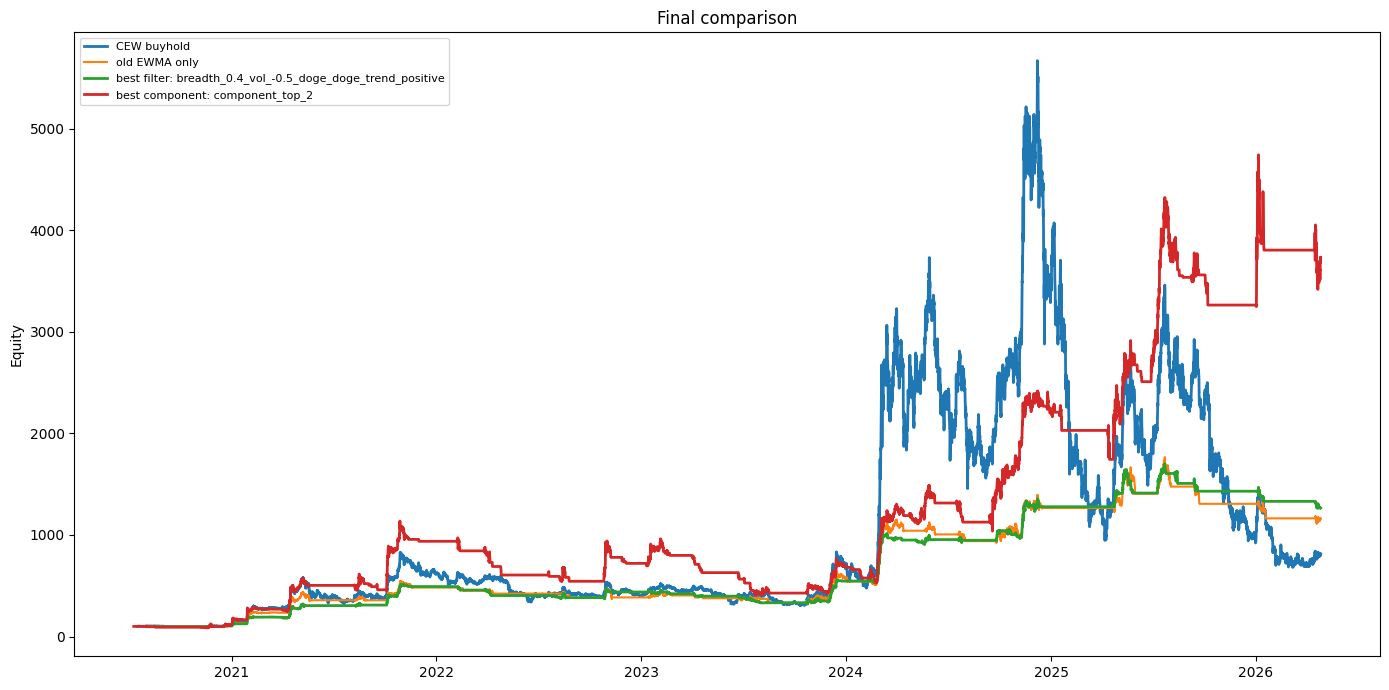

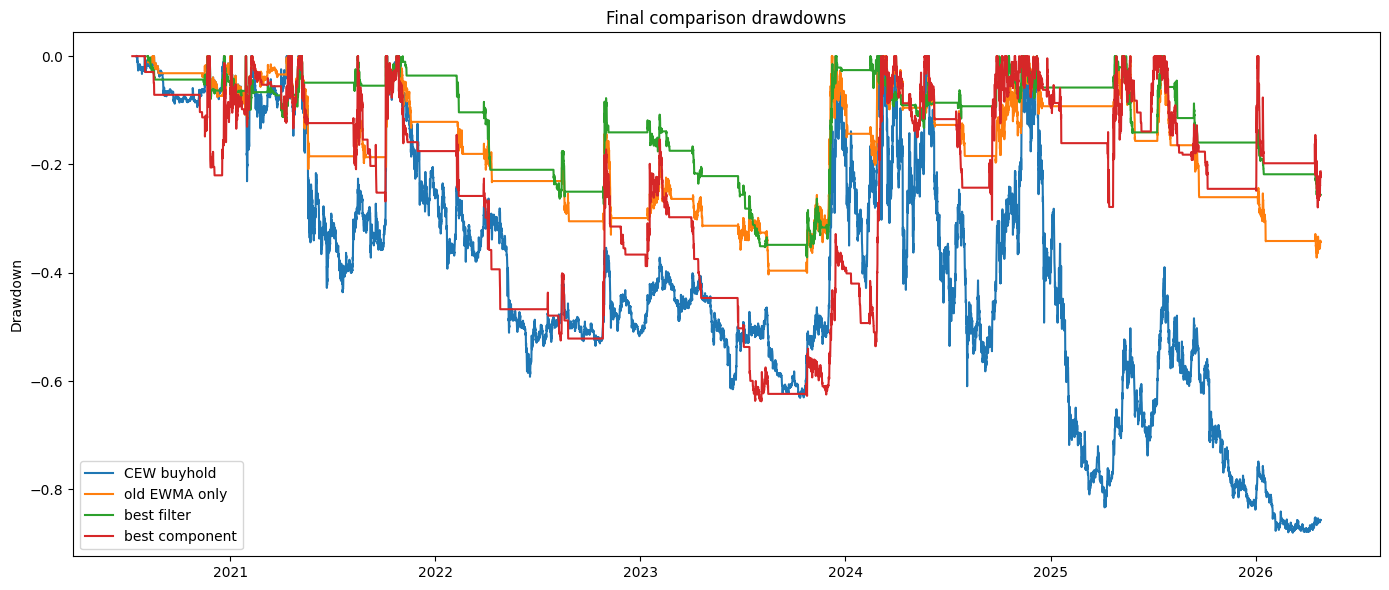

In [30]:
fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(equity_from_returns(index_returns["capped_equal_weight"].dropna()), label="CEW buyhold", linewidth=2)
ax.plot(old_bt["equity"], label="old EWMA only")
ax.plot(best_filter_bt["equity"], label=f"best filter: {best_filter_name}", linewidth=2)
ax.plot(best_component_bt["equity"], label=f"best component: {best_component_name}", linewidth=2)
ax.set_title("Final comparison")
ax.set_ylabel("Equity")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / "final_comparison_equity.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(14, 6))
series_map = {
    "CEW buyhold": equity_from_returns(index_returns["capped_equal_weight"].dropna()),
    "old EWMA only": old_bt["equity"],
    "best filter": best_filter_bt["equity"],
    "best component": best_component_bt["equity"],
}

for name, eq in series_map.items():
    ax.plot(drawdown_series(eq), label=name)
ax.set_title("Final comparison drawdowns")
ax.set_ylabel("Drawdown")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "final_comparison_drawdowns.png", dpi=150)
plt.show()


## Part 19 — Research Summary


In [31]:
def print_research_summary():
    print("=" * 100)
    print("ANIMAL0012 IMPROVEMENT RESEARCH SUMMARY")
    print("=" * 100)

    print("\n1) Data quality")
    display(quality)

    print("\n2) Index metrics")
    display(index_metrics)

    print("\n3) Signal/execution experiment")
    display(sig_exec_results.sort_values("sharpe_like", ascending=False))

    print("\n4) Forecast variant experiment")
    display(forecast_variant_results)

    print("\n5) Filter experiment top 20")
    display(filter_results.head(20))

    print("\n6) Component top-N experiment")
    display(component_results)

    print("\n7) P-value results")
    display(pvalue_results)

    print("\n8) Yearly returns")
    display(yearly)

    print("\n9) Leave-one-coin-out")
    display(loo[[
        "excluded_friendly", "cagr", "ann_vol", "sharpe_like", "max_drawdown",
        "avg_gross_exposure", "ann_turnover"
    ]])

    print("\n10) Final comparison")
    display(final_stats.sort_values("sharpe_like", ascending=False))

    print("\nInterpretation checklist:")
    print("- Did equal-weight signal improve over inverse-vol signal?")
    print("- Did ensemble beat old EWMA-only?")
    print("- Did breadth/volume/DOGE filters improve Sharpe without overfitting?")
    print("- Did component top-N reduce DOGE dependency?")
    print("- Did improvements survive year-by-year?")
    print("- Did p-values support excess returns?")
    print("- Did turnover and costs remain realistic?")


print_research_summary()


ANIMAL0012 IMPROVEMENT RESEARCH SUMMARY

1) Data quality


,symbol,friendly,start,end,rows,expected_4h_bars,missing_4h_bars,duplicate_bars,zero_volume_bars,bad_ohlc_bars,entry_date_after_delay,stale_days_vs_latest
3,DOGEUSDT,DOGE,2020-07-10 08:00:00+00:00,2026-04-26 20:00:00+00:00,12700,12700,0,0,0,0,2020-07-17 08:00:00+00:00,0.000000
2,1000SHIBUSDT,SHIB,2021-05-10 16:00:00+00:00,2026-04-26 20:00:00+00:00,10874,10874,0,0,0,0,2021-05-17 16:00:00+00:00,0.000000
1,1000PEPEUSDT,PEPE,2023-05-05 16:00:00+00:00,2026-04-26 20:00:00+00:00,6524,6524,0,0,0,0,2023-05-12 16:00:00+00:00,0.000000
0,1000BONKUSDT,BONK,2023-11-22 12:00:00+00:00,2026-04-26 20:00:00+00:00,5319,5319,0,0,0,0,2023-11-29 12:00:00+00:00,0.000000
6,WIFUSDT,WIF,2024-01-18 12:00:00+00:00,2026-04-26 20:00:00+00:00,4977,4977,0,0,0,0,2024-01-25 12:00:00+00:00,0.000000
5,POPCATUSDT,POPCAT,2024-08-22 12:00:00+00:00,2026-04-26 20:00:00+00:00,3675,3675,0,0,0,0,2024-08-29 12:00:00+00:00,0.000000
4,PENGUUSDT,PENGU,2024-12-17 16:00:00+00:00,2026-04-26 20:00:00+00:00,2972,2972,0,0,0,0,2024-12-24 16:00:00+00:00,0.000000



2) Index metrics


,name,start,end,bars,years,total_return,cagr,ann_mean,ann_vol,sharpe_like,max_drawdown,calmar,hit_rate,best_bar,worst_bar,skew,kurtosis
0,equal_weight_buyhold,2020-07-17 12:00:00+00:00,2026-04-26 20:00:00+00:00,12657,5.779452,123.314622,1.303607,1.738120,1.408280,1.234215,-0.879445,1.482307,0.499960,1.253744,-0.372638,7.899070,279.587071
1,capped_equal_weight_buyhold,2020-07-17 12:00:00+00:00,2026-04-26 20:00:00+00:00,12657,5.779452,7.137010,0.437258,0.727396,0.856969,0.848801,-0.879445,0.497198,0.500198,0.313436,-0.213498,0.835571,20.222661
2,inverse_vol_buyhold,2020-08-09 12:00:00+00:00,2026-04-26 20:00:00+00:00,12519,5.716438,4.530722,0.348770,0.654477,0.846757,0.772923,-0.874985,0.398601,0.499720,0.313436,-0.208116,0.833317,20.587747



3) Signal/execution experiment


...


9) Leave-one-coin-out


,excluded_friendly,cagr,ann_vol,sharpe_like,max_drawdown,avg_gross_exposure,ann_turnover
2,SHIB,0.594525,0.495642,1.181489,-0.722341,0.140510,53.186325
3,DOGE,0.546236,0.441605,1.201157,-0.500285,0.114671,40.850550
0,BONK,0.792165,0.523551,1.368139,-0.725853,0.164516,64.748139
4,PENGU,0.803463,0.521574,1.383637,-0.637350,0.159490,62.971694
1,PEPE,0.854669,0.519974,1.440076,-0.562440,0.159595,66.108932
5,POPCAT,0.861593,0.520116,1.447825,-0.637350,0.161949,64.179560
6,WIF,0.966654,0.530218,1.532919,-0.637350,0.162139,65.451128



10) Final comparison


,name,start,end,bars,years,total_return,cagr,ann_mean,ann_vol,sharpe_like,max_drawdown,calmar,hit_rate,best_bar,worst_bar,skew,kurtosis,avg_exposure,ann_turnover,total_cost,pct_time_in_market
2,best_filter_breadth_0.4_vol_-0.5_doge_doge_tre...,2020-08-06 12:00:00+00:00,2026-04-26 20:00:00+00:00,12537,5.724658,11.670708,0.558262,0.487070,0.299722,1.625071,-0.371356,1.503307,0.085427,0.251244,-0.062733,8.630904,256.071080,0.120316,95.256502,0.545311,0.165909
3,best_component_component_top_2,2020-07-10 08:00:00+00:00,2026-04-26 20:00:00+00:00,12700,5.799087,36.330183,0.866756,0.757524,0.524211,1.445076,-0.637350,1.359937,0.160945,0.256875,-0.117251,4.646460,84.241482,0.161522,63.004340,0.365368,NaN
1,old_ewma_only,2020-08-06 12:00:00+00:00,2026-04-26 20:00:00+00:00,12537,5.724658,10.618032,0.534831,0.490265,0.355784,1.377982,-0.403102,1.326787,0.182659,0.251244,-0.062733,5.249752,132.413685,0.249617,7.206663,0.041256,0.357342
0,buyhold_capped_equal_weight,2020-07-17 12:00:00+00:00,2026-04-26 20:00:00+00:00,12657,5.779452,7.137010,0.437258,0.727396,0.856969,0.848801,-0.879445,0.497198,0.500198,0.313436,-0.213498,0.835571,20.222661,NaN,NaN,NaN,NaN



Interpretation checklist:
- Did equal-weight signal improve over inverse-vol signal?
- Did ensemble beat old EWMA-only?
- Did breadth/volume/DOGE filters improve Sharpe without overfitting?
- Did component top-N reduce DOGE dependency?
- Did improvements survive year-by-year?
- Did p-values support excess returns?
- Did turnover and costs remain realistic?


## Part 20 — Save Config and Artifacts


In [32]:
config = {
    "data_dir": str(DATA_DIR),
    "interval": INTERVAL,
    "bars_per_day": BARS_PER_DAY,
    "entry_delay_days": ENTRY_DELAY_DAYS,
    "vol_lookback_days": VOL_LOOKBACK_DAYS,
    "ewma_speeds": EWMA_SPEEDS,
    "tsmom_days": TSMOM_DAYS,
    "donchian_days": DONCHIAN_DAYS,
    "regression_days": REGRESSION_DAYS,
    "drawdown_days": DRAWDOWN_DAYS,
    "forecast_cap": FORECAST_CAP,
    "target_vol": TARGET_VOL,
    "max_gross_exposure": MAX_GROSS_EXPOSURE,
    "base_cost_bps": BASE_COST_BPS,
    "best_filter_name": best_filter_name,
    "best_component_name": best_component_name,
    "best_top_n": best_top_n,
}

with open(OUT_DIR / "animal0012_config.json", "w") as f:
    json.dump(config, f, indent=2, default=str)

summary = {
    "quality": quality.to_dict(orient="records"),
    "index_metrics": index_metrics.to_dict(orient="records"),
    "signal_execution": sig_exec_results.to_dict(orient="records"),
    "forecast_variants": forecast_variant_results.to_dict(orient="records"),
    "filter_top20": filter_results.head(20).to_dict(orient="records"),
    "component_results": component_results.to_dict(orient="records"),
    "pvalue_results": pvalue_results.to_dict(orient="records"),
    "yearly": yearly.reset_index().to_dict(orient="records"),
    "leave_one_coin_out": loo.to_dict(orient="records"),
    "final_stats": final_stats.to_dict(orient="records"),
}

with open(OUT_DIR / "animal0012_summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)

print("Saved outputs to:", OUT_DIR.resolve())


Saved outputs to: /home/skier/Documents/animal/animal0012_outputs


## Final Acceptance Checklist

Accept an improvement only if:

### Data

- [ ] No stale symbols.
- [ ] No missing bars inside symbol windows.
- [ ] No duplicate bars.
- [ ] No bad OHLC bars.
- [ ] Listing-date bias handled.

### Strategy

- [ ] Beats old EWMA-only after costs.
- [ ] Beats capped equal-weight buy-and-hold on drawdown-adjusted basis.
- [ ] Does not only work because of DOGE.
- [ ] Survives year-by-year review.
- [ ] Survives leave-one-coin-out.
- [ ] Turnover is realistic.
- [ ] P-values support candidate evidence.

### Next Notebook

```text
animal0013_walkforward_train_selected_filters.ipynb
```

The next version should select filters and thresholds only on training windows, then test on future windows.
